In [ ]:
#import statements 

from pathlib import Path
import numpy as np
import pandas as pd
import pyreadstat
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import roc_auc_score


In [ ]:
#PISA Dataset Preprocessing Data Code 

def LFM_data_from_raw(stu_raw: pd.DataFrame, sch_raw: pd.DataFrame, country: str) -> pd.DataFrame:
    print("Loading student and school data...")
    print("Filtering student and school data for country...")
    stu = stu_raw[stu_raw["CNT"] == country].copy()
    sch = sch_raw[sch_raw["CNT"] == country].copy()

    keep_sch = [c for c in ["CNTSCHID","RATCMP1","RATCMP2","EDUSHORT"] if c in sch.columns]
    if keep_sch:
        sch = sch[["CNTSCHID"] + keep_sch[1:]] if "CNTSCHID" in sch.columns else sch

    print("Merging student + school data...")
    if "CNTSCHID" in stu.columns and "CNTSCHID" in sch.columns:
        df = stu.merge(sch, on="CNTSCHID", how="left")
    else:
        df = stu.copy()  # fall back if CNTSCHID missing
    return df

def process_data_beingbullied(df: pd.DataFrame, predictors: list, dv: str = "BEINGBULLIED") -> pd.DataFrame:
    print("Keeping predictors + DV, encoding gender...")
    cols = [c for c in predictors if c in df.columns]
    if dv not in df.columns:
        raise ValueError(f"DV '{dv}' not in dataframe.")
    keep = list(dict.fromkeys(cols + [dv] + (["CNTSCHID"] if "CNTSCHID" in df.columns else [])))
    df = df[keep].copy()

    # encode gender
    if "ST004D01T" in df.columns:
        df["ST004D01T"] = df["ST004D01T"].map({1:0, 2:1})

    # drop rows with missing DV
    df = df.dropna(subset=[dv])

    # X / y
    X = df.drop(columns=[dv, "CNTSCHID"], errors="ignore")
    print("Dropping columns with all missing values...")
    X = X.dropna(axis=1, how="all")

    print("Imputing missing values and scaling features...")
    imputer = SimpleImputer(strategy="median")
    scaler  = StandardScaler()
    X_imp   = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    X_scl   = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

    X_scl[dv] = df[dv].values
    return X_scl

def process_data_bullying_types(df: pd.DataFrame, predictors: list, RAW_ITEMS) -> pd.DataFrame:
    print("Keeping predictors + raw bullying items, encoding gender...")
    keep_pred = [c for c in predictors if c in df.columns]
    keep_raw  = [c for c in RAW_ITEMS if c in df.columns]
    keep_cols = list(dict.fromkeys(keep_pred + keep_raw + (["CNTSCHID"] if "CNTSCHID" in df.columns else [])))
    df = df[keep_cols].copy()

    if "ST004D01T" in df.columns:
        df["ST004D01T"] = df["ST004D01T"].map({1:0, 2:1})

    print("Creating binary DVs for 4 bullying types...")
    def _bin4(s: pd.Series) -> pd.Series:
        if s.dropna().max() is not None and s.dropna().max() >= 4:
            return s.isin([3,4]).astype(float)
        return s.isin([2,3]).astype(float)

    dv_map = {}
    if "ST038Q04NA" in df.columns: dv_map["BULLY_VERBAL"]     = _bin4(df["ST038Q04NA"])
    if "ST038Q05NA" in df.columns: dv_map["BULLY_THREAT"]     = _bin4(df["ST038Q05NA"])
    if "ST038Q08NA" in df.columns: dv_map["BULLY_RELATIONAL"] = _bin4(df["ST038Q08NA"])
    if {"ST038Q06NA","ST038Q07NA"}.issubset(df.columns):
        dv_map["BULLY_PHYSICAL"] = (_bin4(df["ST038Q06NA"]).astype(bool) | _bin4(df["ST038Q07NA"]).astype(bool)).astype(float)

    if not dv_map:
        raise ValueError("No bullying type items found to create DVs.")

    dv_df = pd.DataFrame(dv_map, index=df.index)

    print("Dropping columns with all missing values...")
    X = df.drop(columns=RAW_ITEMS + ["CNTSCHID"], errors="ignore").dropna(axis=1, how="all")

    print("Imputing missing values and scaling features...")
    imputer = SimpleImputer(strategy="median")
    scaler  = StandardScaler()
    X_imp   = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    X_scl   = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

    final_df = pd.concat([X_scl, dv_df], axis=1)
    return final_df

def best_xgb_reg():
    return XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=4, reg_alpha=0.6, min_child_weight=5,
        objective="reg:squarederror", gamma=0,
        random_state=42, verbosity=0, n_jobs=-1
    )

def best_xgb_clf():
    return XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=4, reg_alpha=0.6, min_child_weight=5,
        objective="binary:logistic", gamma=0, eval_metric="auc",
        random_state=42, verbosity=0, n_jobs=-1
    )




In [5]:
##PISA Finding Bullying Factors Code 

def top10_beingbullied(df_proc: pd.DataFrame, country_label: str) -> pd.DataFrame:
    dv = "BEINGBULLIED"
    if dv not in df_proc.columns:
        raise ValueError(f"{country_label}: '{dv}' not found after processing.")

    X = df_proc.drop(columns=[dv], errors="ignore")
    y = df_proc[dv].values

    # Need at least some non-NaN variance to train
    if len(X.columns) == 0 or np.isclose(X.var(numeric_only=True), 0).all():
        raise ValueError(f"{country_label}: no usable predictors after cleaning.")

    model = best_xgb_reg().fit(X, y)
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

    out = (imp.reset_index()
              .rename(columns={"index":"Feature", 0:"Importance"})
              .assign(Country=country_label, Type="BEINGBULLIED"))
    out["Rank"] = np.arange(1, len(out)+1)
    return out[["Country","Type","Rank","Feature","Importance"]]


def top10_bullying_types(df_proc: pd.DataFrame, country_label: str, DVLIST) -> pd.DataFrame:
    X = df_proc.drop(columns=DVLIST, errors="ignore")
    if X.shape[1] == 0:
        raise ValueError(f"{country_label}: no predictors available.")

    rows = []
    for dv in [c for c in DVLIST if c in df_proc.columns]:
        y = df_proc[dv].dropna().astype(int)
        mask = df_proc[dv].notna()
        Xy = X.loc[mask]

        # skip if only one class
        if y.nunique() < 2:
            print(f"{country_label} — {dv.replace('BULLY_','').title()}: skipped (only one class).")
            continue

        model = best_xgb_clf().fit(Xy, y)
        auc = roc_auc_score(y, model.predict_proba(Xy)[:,1])

        imp = (pd.Series(model.feature_importances_, index=Xy.columns)
                 .sort_values(ascending=False)
                 .head(10))

        tmp = (imp.reset_index()
                 .rename(columns={"index":"Feature", 0:"Importance"})
                 .assign(Country=country_label, Type=dv, AUC=auc))
        tmp["Rank"] = np.arange(1, len(tmp)+1)
        rows.append(tmp[["Country","Type","AUC","Rank","Feature","Importance"]])

    if not rows:
        return pd.DataFrame(columns=["Country","Type","AUC","Rank","Feature","Importance"])
    return pd.concat(rows, ignore_index=True)



In [6]:
STU_PATH = Path("../data/raw/Student Data.sav")
SCH_PATH = Path("../data/raw/School Data.sav")

PROC_DIR   = Path("../data/processed")
RESULT_DIR = Path("../results")
PROC_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

PREDICTORS = [
    #Individual-level Predictors
    "ST004D01T", #Gender
    "AGE", #Age
    "GRADE", #Grade
    "BSMJ", #Expected Occupational Status
    "JOYREAD", #Joy of Reading
    "SCREADCOMP", #Reading Self-Concept: Competence
    "SCREADDIFF", #Reading Self-Concept: Difficulty
    "COMPETE", #Competitiveness
    "WORKMAST", #Work Mastery Orientation
    "GFOFAIL", # General Fear of Failure
    "EUDMO", #Sense of Meaning in Life (Eudaimonia)  
    "RESILIENCE", #Resilience
    "MASTGOAL", #Mastery Goal Orientation
    "ST185Q01HA", #Does life has meaning/purpose 
    "ST184Q01HA", #Growth Mindset
    "SWBP", #Well Being 
    "PV1MATH", #Math Performance
    "PV1READ", #Reading Performance
    "PV1SCIE", #Science Performance
    "ST207Q01HA", #Irritation feeling when other students are bullied
    "ST207Q02HA", #Feeling of whether it's good or not to help students who can't defend themselves
    "ST207Q03HA", #Is it wrong to join in bullying others
    "ST207Q04HA", #How you feel when you see other students being bullied
    "ST207Q05HA", #Liking when you see other students being bullied

    #Proximal-level Predictors
    "REPEAT", #Grade Repetition History
    "UNDREM", #Meta-cognition: Understanding & Remembering 
    "METASUM", #Meta-cognition: Summarizing
    "METASPAM", #Meta-cognition: Assessing Credibility

    #Microsystem-Level Factors (Family, Peers, & School CLimate)
    "EMOSUPS", #Parental Emotional Support
    "DURECEC", #Duration in Early Childhood Education and Care
    "BELONG", #School Belonging
    "PERCOMP", #Perceived School Competitiveness 
    "PERCOOP", #Perceived School Cooperation
    "ATTLNACT", #Attitudes Towards Learning Activities
    "DISCLIMA", #Disciplinary Climate (Language Lessons)
    "TEACHSUP", #Teacher Support (Language Lessons)
    "DIRINS", #Teacher-Directed Instruction 
    "PERFEED", #Perceived Feedback from Teachers
    "STIMREAD", #Teacher's Stimulation of Reading Engagement
    "ADAPTIVITY", #Adapation of Instruction
    "TEACHINT", #Perceived Teacher Interest 
    "ST206Q01HA", #How students value cooperation 
    "PA006Q09TA" #School Climate

    #Macrosystem/Exosystem-level Predictors
    "ESCS", #Family Socioeconomic Status(Index)
    "EDUSHORT", #Shortage of Educational Resources
    "RATCMP1", #Number of Computers per Student
    "RATCMP2", #Percentage of Computers Connected to the Internet                    
]

RAW_TYPE_ITEMS = ["ST038Q04NA","ST038Q05NA","ST038Q06NA","ST038Q07NA","ST038Q08NA"]
DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]

error_log = []
def log_error(iso3, stage, err):
    msg = f"{iso3} | {stage} | {type(err).__name__}: {err}"
    print("!!", msg)
    error_log.append({"country": iso3, "stage": stage, "error": str(err)})


print("Preloading raw PISA files once...")
stu_raw, _ = pyreadstat.read_sav(STU_PATH, apply_value_formats=False)
sch_raw, _ = pyreadstat.read_sav(SCH_PATH, apply_value_formats=False)
print("Preload complete.")

# Figure out all 2018 ISO3 country codes directly from the data
ALL_ISO3 = sorted(stu_raw["CNT"].dropna().unique().tolist())

# Containers for outputs
rows_being = []
rows_types = []
prev_rows  = []

for iso3 in ALL_ISO3:
    try:
        print(f"\nPreprocessing PISA data for {iso3}...")
        df_merged = LFM_data_from_raw(stu_raw, sch_raw, iso3)

        try:
            df_being = process_data_beingbullied(df_merged, PREDICTORS, dv="BEINGBULLIED")
            # save processed per-country
            outp = PROC_DIR / f"{iso3}_DVBEING_data.pkl"
            df_being.to_pickle(outp)
            print(f"Saved processed BEINGBULLIED → {outp} (shape: {df_being.shape})")

            # prevalence proxy = mean of DV (works if 0/1 or standardized index)
            prev_rows.append({"Country": iso3, "Type": "BEINGBULLIED", "Prevalence": float(np.nanmean(df_being["BEINGBULLIED"]))})

            # top10
            try:
                top10 = top10_beingbullied(df_being, iso3)
                rows_being.append(top10)
                # pretty print
                print(f"Top 10 XGB predictors of BEINGBULLIED ( {iso3} ):")
                for _, r in top10.iterrows():
                    print(f" {int(r['Rank']):2d}. {r['Feature']:<12s}: {r['Importance']:.4f}")
            except Exception as e:
                log_error(iso3, "top10_beingbullied", e)

        except Exception as e:
            log_error(iso3, "process_data_beingbullied", e)

        try:
            df_types = process_data_bullying_types(df_merged, PREDICTORS, RAW_TYPE_ITEMS)
            outp2 = PROC_DIR / f"{iso3}_bully_types_data.pkl"
            df_types.to_pickle(outp2)
            print(f"Saved processed BullyTypes → {outp2} (shape: {df_types.shape})")

            # Prevalence for each binary type (mean of 0/1)
            for dv in [c for c in DV_TYPES if c in df_types.columns]:
                prev_rows.append({"Country": iso3, "Type": dv, "Prevalence": float(np.nanmean(df_types[dv]))})

            # top10 per type
            try:
                top_types = top10_bullying_types(df_types, iso3, DV_TYPES)
                rows_types.append(top_types)
                # optional pretty print (short)
                if not top_types.empty:
                    for dv in top_types["Type"].unique():
                        sub = top_types[top_types["Type"]==dv]
                        auc = sub["AUC"].iloc[0]
                        print(f"{iso3} — {dv.replace('BULLY_','').title()} (ROC-AUC {auc:.3f})")
                        for _, r in sub.iterrows():
                            print(f" {int(r['Rank']):2d}. {r['Feature']:<12s}: {r['Importance']:.4f}")
            except Exception as e:
                log_error(iso3, "top10_bullying_types", e)

        except Exception as e:
            log_error(iso3, "process_data_bullying_types", e)

    except Exception as e:
        log_error(iso3, "LFM_data_from_raw", e)

df_being_all = pd.concat(rows_being, ignore_index=True) if rows_being else pd.DataFrame(columns=["Country","Type","Rank","Feature","Importance"])
df_types_all = pd.concat(rows_types, ignore_index=True) if rows_types else pd.DataFrame(columns=["Country","Type","AUC","Rank","Feature","Importance"])
df_prev      = pd.DataFrame(prev_rows)

df_being_all.to_csv(RESULT_DIR / "beingbullied_top10.csv", index=False)
df_types_all.to_csv(RESULT_DIR / "bullying_types_top10.csv", index=False)
df_prev.to_csv(RESULT_DIR / "bullying_prevalence.csv", index=False)

pd.DataFrame(error_log).to_csv(RESULT_DIR / "errors_log.csv", index=False)
print("\nSaved:")
print(" - results/beingbullied_top10.csv")
print(" - results/bullying_types_top10.csv")
print(" - results/bullying_prevalence.csv")
print(" - results/errors_log.csv")

def add_points(df_long, has_auc=False):
    if df_long.empty: 
        return df_long
    pts_map = {1:10,2:9,3:8,4:7,5:6,6:5,7:4,8:3,9:2,10:1}
    out = df_long.copy()
    out["Points"] = out["Rank"].map(pts_map).fillna(0).astype(int)
    return out

being_pts = add_points(df_being_all, has_auc=False)
types_pts = add_points(df_types_all, has_auc=True)

# Global totals by feature (separately for BEINGBULLIED and for each Type)
agg_being = (being_pts.groupby("Feature", as_index=False)["Points"].sum()
                        .sort_values("Points", ascending=False))
agg_types = (types_pts.groupby(["Type","Feature"], as_index=False)["Points"].sum()
                        .sort_values(["Type","Points"], ascending=[True, False]))

agg_being.to_csv(RESULT_DIR / "aggregate_points_BEINGBULLIED.csv", index=False)
agg_types.to_csv(RESULT_DIR / "aggregate_points_byType.csv", index=False)

print("\nSaved:")
print(" - results/aggregate_points_BEINGBULLIED.csv")
print(" - results/aggregate_points_byType.csv")



Preloading raw PISA files once...
Preload complete.

Preprocessing PISA data for ALB...
Loading student and school data...
Filtering student and school data for country...
Merging student + school data...
Keeping predictors + DV, encoding gender...
Dropping columns with all missing values...
Imputing missing values and scaling features...
Saved processed BEINGBULLIED → ..\data\processed\ALB_DVBEING_data.pkl (shape: (5899, 46))
Top 10 XGB predictors of BEINGBULLIED ( ALB ):
  1. BELONG      : 0.0847
  2. ST004D01T   : 0.0526
  3. ATTLNACT    : 0.0379
  4. PV1READ     : 0.0336
  5. GFOFAIL     : 0.0315
  6. JOYREAD     : 0.0314
  7. EMOSUPS     : 0.0286
  8. SCREADDIFF  : 0.0278
  9. ST207Q03HA  : 0.0272
 10. PV1MATH     : 0.0262
Keeping predictors + raw bullying items, encoding gender...
Creating binary DVs for 4 bullying types...
Dropping columns with all missing values...
Imputing missing values and scaling features...
Saved processed BullyTypes → ..\data\processed\ALB_bully_types_dat

C:\Users\adhiv\AppData\Local\Temp\ipykernel_29388\1388439792.py:150: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_types_all = pd.concat(rows_types, ignore_index=True) if rows_types else pd.DataFrame(columns=["Country","Type","AUC","Rank","Feature","Importance"])


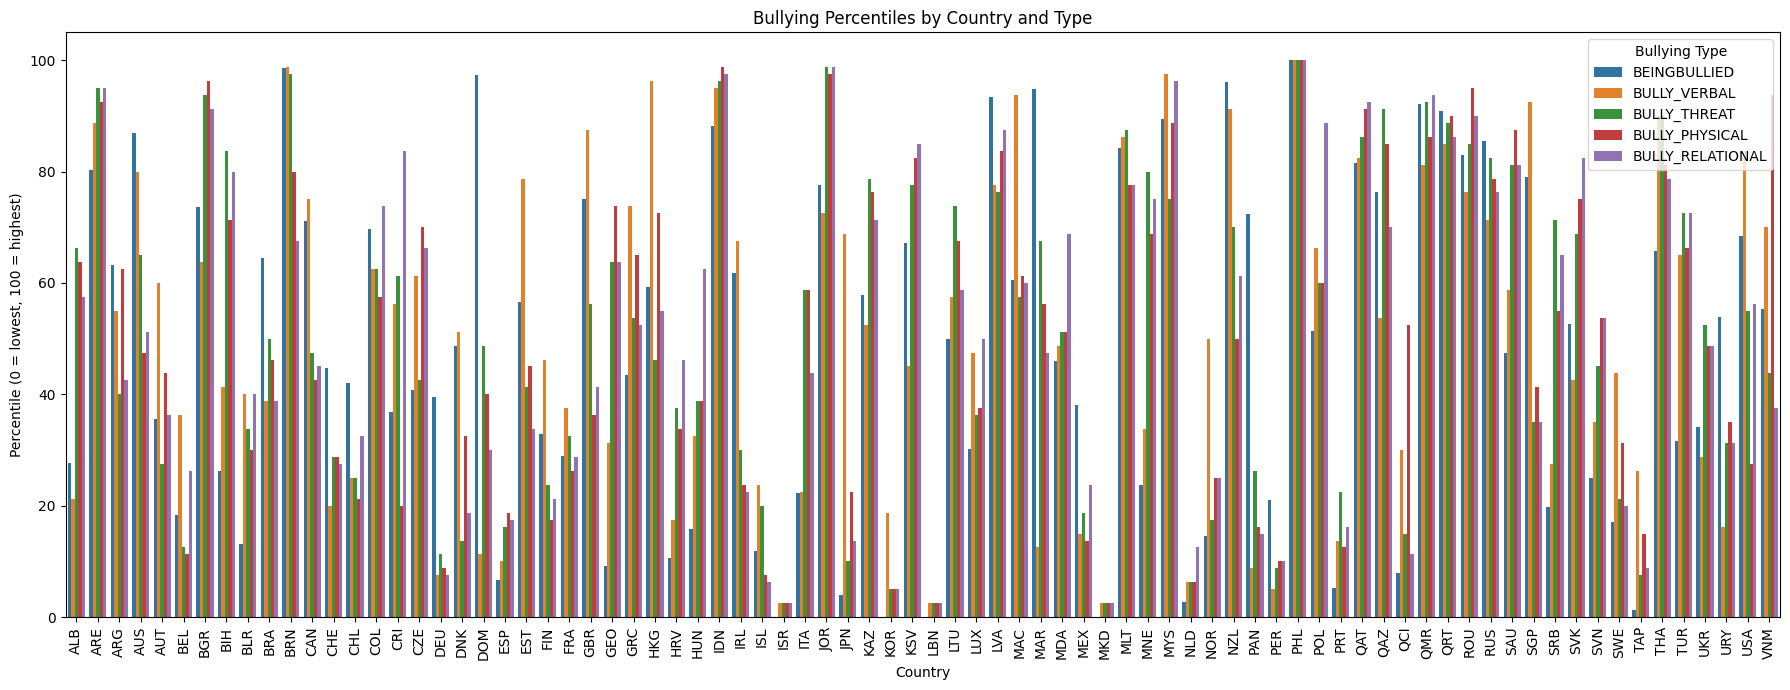

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata

# Load data
df_prev = pd.read_csv("../results/bullying_prevalence.csv")

# Convert Prevalence into percentiles separately for each Type
df_prev["Percentile"] = df_prev.groupby("Type")["Prevalence"].transform(
    lambda x: rankdata(x, method="average") / len(x) * 100
)

# --- Grouped Plot: All Bullying Types Percentiles ---
plt.figure(figsize=(18,7))
sns.barplot(
    x="Country", y="Percentile", hue="Type",
    data=df_prev, dodge=True
)
plt.xticks(rotation=90)
plt.title("Bullying Percentiles by Country and Type")
plt.ylabel("Percentile (0 = lowest, 100 = highest)")
plt.xlabel("Country")
plt.legend(title="Bullying Type")
plt.tight_layout()
plt.show()


C:\Users\adhiv\AppData\Local\Temp\ipykernel_29388\2731718259.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


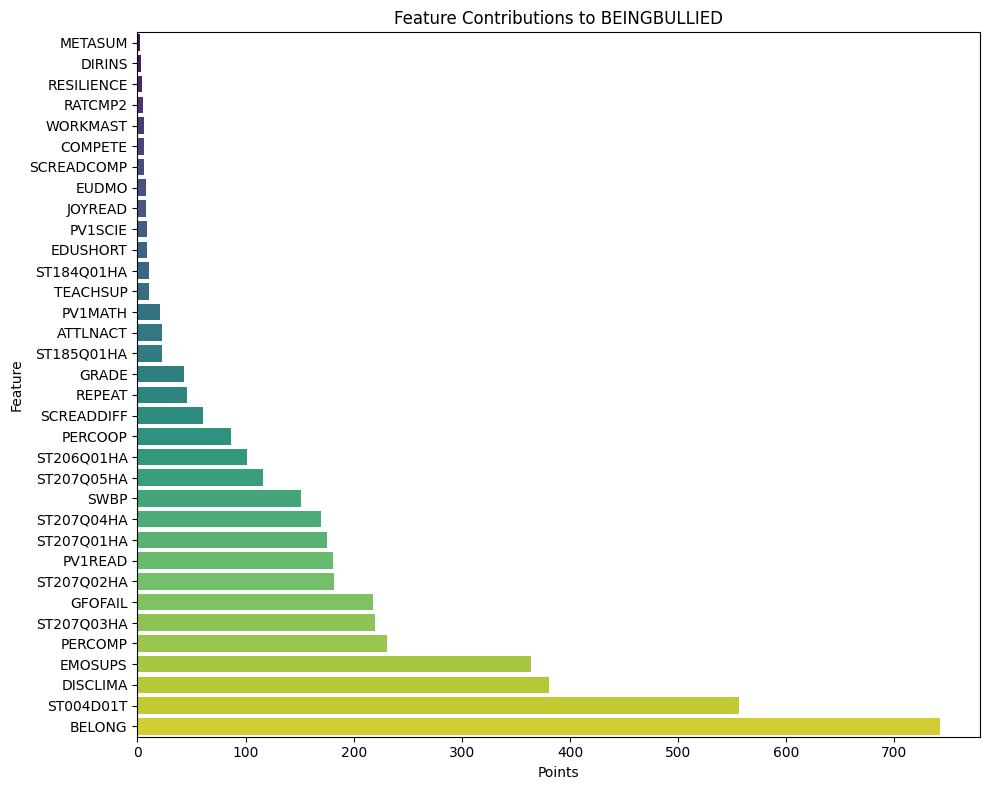

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_points = pd.read_csv("../results/aggregate_points_BEINGBULLIED.csv")

# Sort by Points descending
df_points = df_points.sort_values("Points", ascending=True)  # ascending for horizontal plot

# Plot horizontal bar chart
plt.figure(figsize=(10,8))
sns.barplot(
    x="Points", y="Feature",
    data=df_points,
    palette="viridis"
)
plt.title("Feature Contributions to BEINGBULLIED")
plt.xlabel("Points")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


C:\Users\adhiv\AppData\Local\Temp\ipykernel_29388\1740984171.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_type_sorted = df_type.groupby("Type", group_keys=False).apply(
C:\Users\adhiv\AppData\Local\Temp\ipykernel_29388\1740984171.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


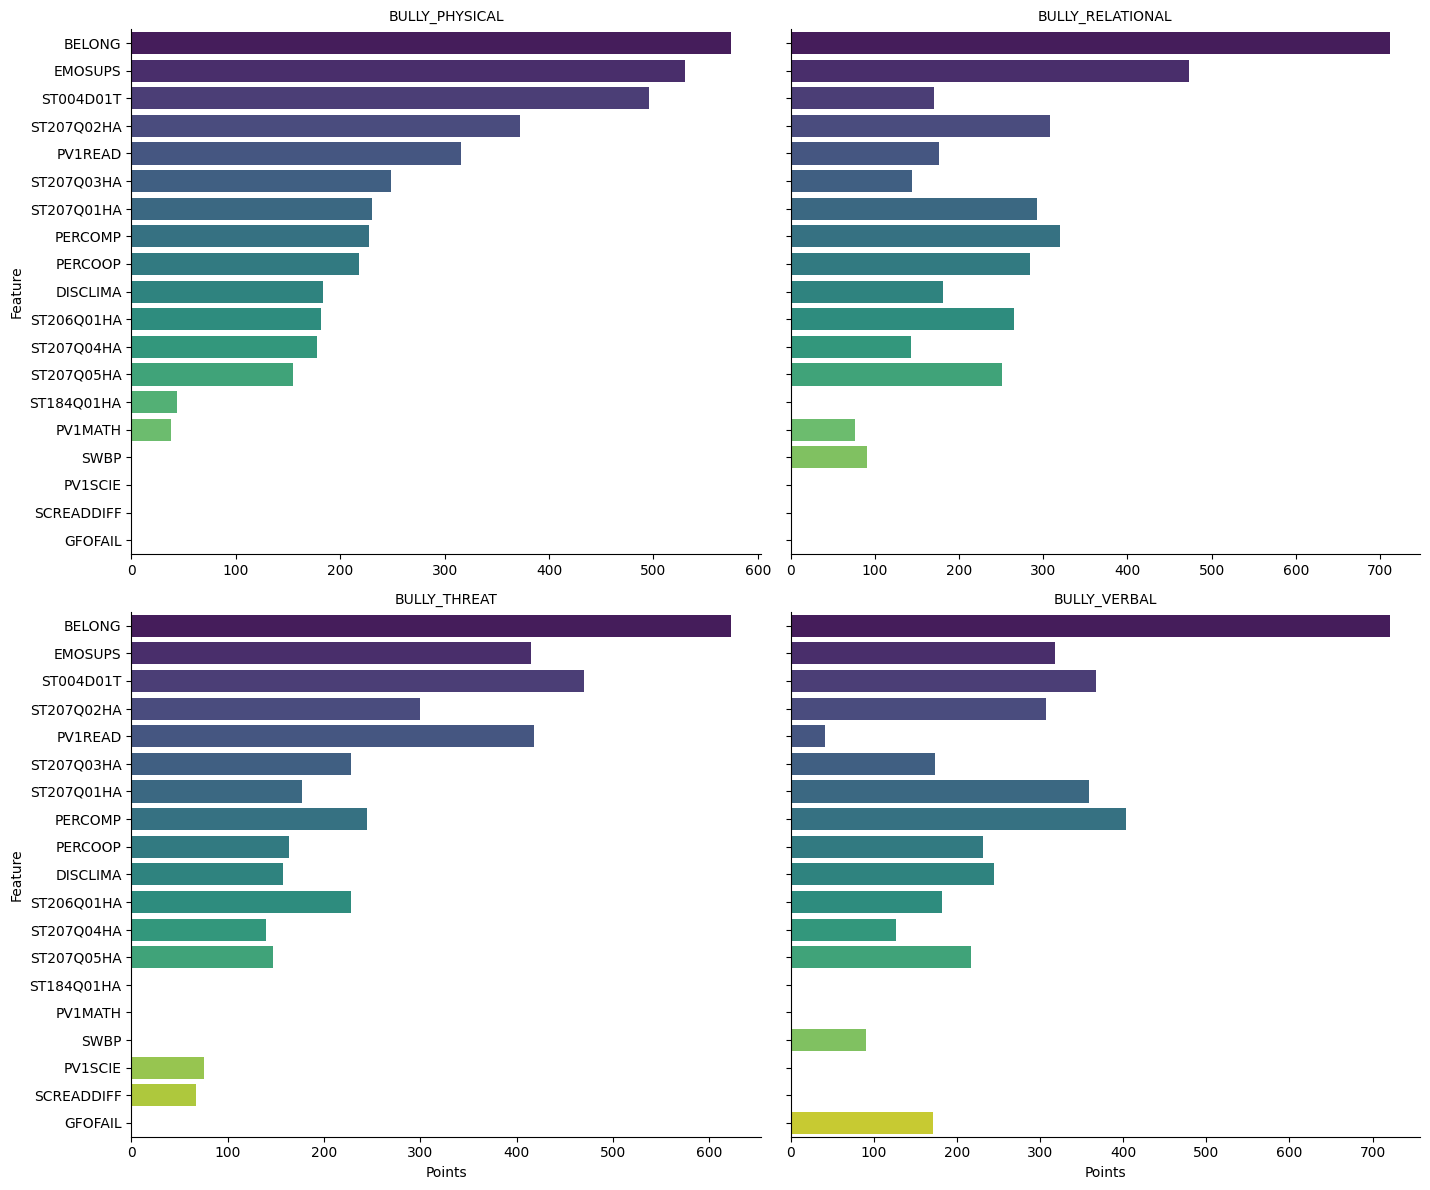

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_type = pd.read_csv("../results/aggregate_points_byType.csv")

# Sort features within each Type
df_type_sorted = df_type.groupby("Type", group_keys=False).apply(
    lambda x: x.sort_values("Points", ascending=False).head(15)  # top 15 features per type
)

# Plot faceted barplots
g = sns.catplot(
    data=df_type_sorted,
    x="Points", y="Feature",
    col="Type", col_wrap=2,  # 2 columns of subplots
    kind="bar", sharex=False, height=6, aspect=1.2, palette="viridis"
)

g.set_titles("{col_name}")
g.set_axis_labels("Points", "Feature")
plt.tight_layout()
plt.show()


In [1]:
# Graphs: prevalence per country (4 binary types as %), plus BEINGBULLIED (z & percentile).
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths
RESULT_DIR = Path("../results")
PLOT_DIR = RESULT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]

# Load prevalence
df_prev = pd.read_csv(RESULT_DIR / "bullying_prevalence.csv")  # Country, Type, Prevalence

def norm_cdf(z: float) -> float:
    """Standard normal CDF for z->percentile (no SciPy)."""
    return 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))

def save_sorted_bar(series: pd.Series, title: str, xlabel: str, outpath: Path, percent=False):
    s = series.dropna()
    if s.empty:
        print(f"[skip] {title} (no data)")
        return
    s = s.sort_values(ascending=True)  # for barh: largest on top
    H = max(4, 0.25*len(s))
    plt.figure(figsize=(12, H))
    y = np.arange(len(s))
    plt.barh(y, s.values)
    plt.yticks(y, s.index, fontsize=8)
    plt.xlabel(xlabel + (" (%)" if percent else ""))
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=220)
    plt.close()

# 4 binary types as %
for dv in DV_TYPES:
    sub = df_prev[df_prev["Type"]==dv].dropna(subset=["Prevalence"])
    if sub.empty:
        print(f"[prevalence] no data for {dv}")
        continue
    ser_pct = pd.Series(sub["Prevalence"].values*100.0, index=sub["Country"].values)
    save_sorted_bar(
        ser_pct,
        title=f"Prevalence of {dv.replace('BULLY_','').title()} Bullying by Country",
        xlabel="Prevalence",
        outpath=PLOT_DIR / f"01_prevalence_{dv}.png",
        percent=True
    )

# BEINGBULLIED: (A) z-score mean
subz = df_prev[df_prev["Type"]=="BEINGBULLIED"].dropna(subset=["Prevalence"])
if not subz.empty:
    ser_z = pd.Series(subz["Prevalence"].values, index=subz["Country"].values)
    save_sorted_bar(
        ser_z,
        title="BEINGBULLIED — Country Mean of Standardized Index (z)",
        xlabel="Mean z-score",
        outpath=PLOT_DIR / "02_prevalence_BEINGBULLIED_z.png",
        percent=False
    )
    # (B) z -> percentile (readable, but NOT a literal % bullied)
    ser_pct = ser_z.apply(lambda z: 100.0*norm_cdf(z))
    save_sorted_bar(
        ser_pct,
        title="BEINGBULLIED — Mean Converted to Percentile via Normal CDF",
        xlabel="Percentile",
        outpath=PLOT_DIR / "03_prevalence_BEINGBULLIED_percentile.png",
        percent=True
    )

print("Saved prevalence charts →", PLOT_DIR)
# NOTE: To get a literal “% bullied”, you must binarize raw bullying items at a chosen threshold and average per country.


Saved prevalence charts → ..\results\plots


In [2]:
# Graphs: global aggregate of predictors (BEINGBULLIED + each type).
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = Path("../results")
PLOT_DIR = RESULT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]

# Load aggregates produced by your pipeline
df_agg_being = pd.read_csv(RESULT_DIR / "aggregate_points_BEINGBULLIED.csv")   # Feature, Points
df_agg_types = pd.read_csv(RESULT_DIR / "aggregate_points_byType.csv")        # Type, Feature, Points

def plot_agg(df_feat_points: pd.DataFrame, title: str, outpath: Path, top_n=None):
    d = df_feat_points.copy()
    if d.empty:
        print(f"[skip] {title} (no data)")
        return
    if top_n:
        d = d.sort_values("Points", ascending=False).head(top_n)
    d = d.sort_values("Points", ascending=True)  # for barh
    H = max(4, 0.30*len(d))
    plt.figure(figsize=(12, H))
    y = np.arange(len(d))
    plt.barh(y, d["Points"].values)
    plt.yticks(y, d["Feature"].values, fontsize=8)
    plt.xlabel("Aggregate Points")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=220)
    plt.close()

# BEINGBULLIED global
plot_agg(
    df_agg_being,
    title="Global Aggregate of Predictors — BEINGBULLIED",
    outpath=PLOT_DIR / "04_agg_predictors_BEINGBULLIED_global.png",
    top_n=None
)

# Each type global
for dv in DV_TYPES:
    sub = df_agg_types[df_agg_types["Type"]==dv][["Feature","Points"]]
    plot_agg(
        sub,
        title=f"Global Aggregate of Predictors — {dv.replace('BULLY_','').title()}",
        outpath=PLOT_DIR / f"05_agg_predictors_{dv}_global.png",
        top_n=None
    )

print("Saved global aggregate charts →", PLOT_DIR)


Saved global aggregate charts → ..\results\plots


In [ ]:
# Graphs: per-country top-10 aggregate predictors ordered by prevalence (one PDF per DV).
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

RESULT_DIR = Path("../results")
PLOT_DIR = RESULT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]

# Load
df_prev    = pd.read_csv(RESULT_DIR / "bullying_prevalence.csv")       # Country, Type, Prevalence
df_being10 = pd.read_csv(RESULT_DIR / "beingbullied_top10.csv")        # Country,Type,Rank,Feature,Importance
df_types10 = pd.read_csv(RESULT_DIR / "bullying_types_top10.csv")      # Country,Type,AUC,Rank,Feature,Importance

POINTS_MAP = {1:10,2:9,3:8,4:7,5:6,6:5,7:4,8:3,9:2,10:1}
def add_points(df_long: pd.DataFrame):
    out = df_long.copy()
    out["Points"] = out["Rank"].map(POINTS_MAP).fillna(0).astype(int)
    return out

def countries_by_prevalence(dv: str):
    tmp = df_prev[df_prev["Type"]==dv].dropna(subset=["Prevalence"])
    return tmp.sort_values("Prevalence", ascending=False)["Country"].tolist()

def save_country_pdf(dv: str, df_pts: pd.DataFrame, out_pdf: Path):
    order = countries_by_prevalence(dv)
    if not order:
        print(f"[skip] {dv} (no prevalence)")
        return
    with PdfPages(out_pdf) as pdf:
        for c in order:
            sub = df_pts[df_pts["Country"]==c]
            if sub.empty: 
                continue
            feat = (sub.groupby("Feature", as_index=False)["Points"]
                      .sum()
                      .sort_values("Points", ascending=True))
            plt.figure(figsize=(10, 4.5))
            y = np.arange(len(feat))
            plt.barh(y, feat["Points"].values)
            plt.yticks(y, feat["Feature"].values, fontsize=8)
            plt.xlabel("Aggregate Points")
            prev = df_prev[(df_prev["Type"]==dv)&(df_prev["Country"]==c)]["Prevalence"]
            subtitle = "" if prev.empty else (f"(prevalence={prev.values[0]*100:.1f}%)" if dv!="BEINGBULLIED" else f"(mean z={prev.values[0]:.2f})")
            plt.title(f"{dv} — {c} {subtitle}")
            plt.tight_layout()
            pdf.savefig(dpi=200)
            plt.close()
    print(f"Saved → {out_pdf.name}")

# BEINGBULLIED
being_pts = add_points(df_being10[["Country","Type","Rank","Feature"]])
save_country_pdf("BEINGBULLIED", being_pts, PLOT_DIR / "06_country_top10_BEINGBULLIED.pdf")

# 4 types
types_pts = add_points(df_types10[["Country","Type","Rank","Feature"]])
for dv in DV_TYPES:
    save_country_pdf(dv, types_pts[types_pts["Type"]==dv], PLOT_DIR / f"07_country_top10_{dv}.pdf")

print("Saved per-country top-10 PDFs →", PLOT_DIR)


Saved → 06_country_top10_BEINGBULLIED.pdf
Saved → 07_country_top10_BULLY_VERBAL.pdf
Saved → 07_country_top10_BULLY_THREAT.pdf
Saved → 07_country_top10_BULLY_PHYSICAL.pdf
Saved → 07_country_top10_BULLY_RELATIONAL.pdf
Saved per-country top-10 PDFs → ..\results\plots


In [6]:
# Full-ranking footrule ("footlong") + PAM clustering + cluster aggregates for ALL predictors per country
# Outputs go to ../results/plots/

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import silhouette_score
from xgboost import XGBRegressor, XGBClassifier

# K-medoids (PAM)
try:
    from sklearn_extra.cluster import KMedoids
    HAVE_SKLEARN_EXTRA = True
except Exception:
    HAVE_SKLEARN_EXTRA = False

# Optional 2D layout for visualization
try:
    from sklearn.manifold import MDS
    HAVE_MDS = True
except Exception:
    HAVE_MDS = False

# ---------- Paths & constants ----------
PROC_DIR   = Path("../data/processed")
RESULT_DIR = Path("../results")
PLOT_DIR   = RESULT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES

# Countries to consider per DV come from your prevalence file
df_prev = pd.read_csv(RESULT_DIR / "bullying_prevalence.csv")

# ---------- Helpers: fit importances over ALL predictors ----------
def _fit_being_importances(country: str):
    p = PROC_DIR / f"{country}_DVBEING_data.pkl"
    if not p.exists():
        return None
    df = pd.read_pickle(p)
    if "BEINGBULLIED" not in df.columns:
        return None
    X = df.drop(columns=["BEINGBULLIED"], errors="ignore")
    y = df["BEINGBULLIED"].values
    if X.shape[1] < 2 or np.isclose(X.var(numeric_only=True), 0).all():
        return None
    m = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=4, reg_alpha=0.6,
        min_child_weight=5, objective="reg:squarederror",
        random_state=42, n_jobs=-1, verbosity=0
    ).fit(X, y)
    s = pd.Series(m.feature_importances_, index=X.columns)
    return s if s.sum() > 0 else None

def _fit_type_importances(country: str, dv: str):
    p = PROC_DIR / f"{country}_bully_types_data.pkl"
    if not p.exists():
        return None
    df = pd.read_pickle(p)
    if dv not in df.columns:
        return None
    mask = df[dv].notna()
    if mask.sum() < 10 or df[dv].nunique() < 2:
        return None
    X = df.loc[mask].drop(columns=[dv], errors="ignore")
    y = df.loc[mask, dv].astype(int).values
    if X.shape[1] < 2 or y.max() == y.min():
        return None
    m = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=4, reg_alpha=0.6,
        min_child_weight=5, objective="binary:logistic", eval_metric="auc",
        random_state=42, n_jobs=-1, verbosity=0
    ).fit(X, y)
    s = pd.Series(m.feature_importances_, index=X.columns)
    return s if s.sum() > 0 else None

def _normalize(imp: pd.Series) -> pd.Series:
    s = imp.clip(lower=0)
    tot = s.sum()
    return s / tot if tot > 0 else s

# ---------- Footrule (full ranking) ----------
def build_fullrank_distance_and_imps(countries: list, dv: str):
    """
    Returns:
      countries_fr: ordered list of countries kept
      D: full footrule distance matrix (numpy array)
      imp_norm: dict {country: normalized importances (Series)}
    """
    # per-country importances (all predictors)
    imp_dict = {}
    for c in countries:
        s = _fit_being_importances(c) if dv == "BEINGBULLIED" else _fit_type_importances(c, dv)
        if s is not None:
            imp_dict[c] = s
    if len(imp_dict) < 3:
        return None, None, None

    # ranks over union of features
    rank_dict = {c: imp.rank(ascending=False, method="average") for c, imp in imp_dict.items()}
    feats = sorted({f for r in rank_dict.values() for f in r.index})
    worst = float(len(feats) + 1)

    countries_fr = sorted(rank_dict.keys())
    R = np.vstack([[float(rank_dict[c].get(f, worst)) for f in feats] for c in countries_fr])

    n = len(countries_fr)
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            d = np.abs(R[i] - R[j]).sum()
            D[i, j] = D[j, i] = d

    # normalized importances for later cluster aggregates
    imp_norm = {c: _normalize(imp_dict[c]) for c in countries_fr}

    return countries_fr, D, imp_norm

def save_heatmap(mat_df: pd.DataFrame, title: str, outpath: Path, cmap="viridis"):
    if mat_df.empty:
        return
    plt.figure(figsize=(10, 8))
    plt.imshow(mat_df.values, aspect='auto', interpolation='nearest', cmap=cmap)
    plt.colorbar(label="Spearman Footrule Distance")
    plt.xticks(range(len(mat_df.columns)), mat_df.columns, rotation=90, fontsize=7)
    plt.yticks(range(len(mat_df.index)),   mat_df.index, fontsize=7)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=250)
    plt.close()

def save_pairs_long(mat_df: pd.DataFrame, outpath: Path):
    rows, cols = [], mat_df.columns.tolist()
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            rows.append({"Country1": cols[i], "Country2": cols[j], "Footrule": float(mat_df.iloc[i, j])})
    pd.DataFrame(rows).to_csv(outpath, index=False)

# ---------- PAM (K-medoids) ----------
def run_kmedoids_precomputed(D: np.ndarray, k: int, random_state: int = 42):
    if HAVE_SKLEARN_EXTRA:
        model = KMedoids(n_clusters=k, metric="precomputed", init="k-medoids++", random_state=random_state)
        labels = model.fit_predict(D)
        return labels
    # tiny fallback: greedy init + local swaps
    n = D.shape[0]
    chosen = [np.argmin(D.sum(axis=1))]
    while len(chosen) < k:
        remaining = [i for i in range(n) if i not in chosen]
        dmin = np.min(D[np.ix_(remaining, chosen)], axis=1)
        chosen.append(remaining[int(np.argmax(dmin))])
    medoids = np.array(chosen, dtype=int)
    def assign(meds): return np.argmin(D[:, meds], axis=1)
    labels = assign(medoids)
    improved = True
    while improved:
        improved = False
        for m_idx in range(k):
            for i in range(n):
                if i in medoids: 
                    continue
                trial = medoids.copy(); trial[m_idx] = i
                tl = assign(trial)
                tcost = np.sum([D[p, trial[tl[p]]] for p in range(n)])
                ccost = np.sum([D[p, medoids[labels[p]]] for p in range(n)])
                if tcost + 1e-9 < ccost:
                    medoids, labels = trial, tl
                    improved = True
    return labels

def choose_k_by_silhouette(D: np.ndarray, k_min=2, k_max=10):
    best_k, best_s = None, -1
    upper = min(k_max, D.shape[0]-1)
    for k in range(k_min, max(k_min, upper)+1):
        if k < 2: 
            continue
        labels = run_kmedoids_precomputed(D, k)
        s = silhouette_score(D, labels, metric="precomputed")
        if s > best_s:
            best_s, best_k = s, k
    return best_k, best_s

def mds_scatter(countries, D, labels, title, outpath: Path):
    if not HAVE_MDS:
        print("[MDS] unavailable; skipping scatter.")
        return
    XY = MDS(n_components=2, dissimilarity="precomputed", random_state=42).fit_transform(D)
    plt.figure(figsize=(8, 6))
    for cl in sorted(np.unique(labels)):
        idx = np.where(labels == cl)[0]
        plt.scatter(XY[idx, 0], XY[idx, 1], label=f"Cluster {cl}", s=30)
        for i in idx:
            plt.text(XY[i, 0], XY[i, 1], countries[i], fontsize=7)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.close()

# ---------- Cluster aggregates (normalized importances) ----------
def save_cluster_normimp_pdf(imp_norm: dict, countries: list, labels: np.ndarray,
                             title_prefix: str, out_pdf: Path, top_n: int = 15):
    c2cl = {c: int(labels[i]) for i, c in enumerate(countries)}
    # aggregate normalized importances within each cluster
    clusters = sorted(np.unique(labels))
    with PdfPages(out_pdf) as pdf:
        for cl in clusters:
            members = [c for c in countries if c in imp_norm and c2cl[c] == cl]
            if not members:
                continue
            feats = sorted({f for c in members for f in imp_norm[c].index})
            agg = pd.Series(0.0, index=feats)
            for c in members:
                agg = agg.add(imp_norm[c].reindex(feats).fillna(0.0), fill_value=0.0)
            top = agg.sort_values(ascending=False).head(top_n).sort_values(ascending=True)

            plt.figure(figsize=(10, max(4, 0.4*len(top))))
            y = np.arange(len(top))
            plt.barh(y, top.values)
            plt.yticks(y, top.index, fontsize=8)
            plt.xlabel("Sum of normalized importances")
            plt.title(f"{title_prefix} — Cluster {cl}")
            plt.tight_layout()
            pdf.savefig(dpi=200)
            plt.close()

# ---------- Run for each DV ----------
for dv in ALL_DVS:
    countries_input = sorted(df_prev[df_prev["Type"] == dv]["Country"].unique().tolist())
    if not countries_input:
        print(f"[{dv}] no countries found in prevalence file; skipping.")
        continue

    print(f"\n[{dv}] Fitting all-predictor importances per country...")
    countries, D, imp_norm = build_fullrank_distance_and_imps(countries_input, dv)
    if countries is None:
        print(f"[{dv}] Not enough valid countries after fitting; skipping.")
        continue

    # Save footrule matrix + pairs + heatmap
    M = pd.DataFrame(D, index=countries, columns=countries)
    M.to_csv(PLOT_DIR / f"08b_footrule_matrix_{dv}_fullrank.csv", index=True)
    save_pairs_long(M, PLOT_DIR / f"09b_footrule_pairs_{dv}_fullrank.csv")
    save_heatmap(M, f"Footrule Heatmap — {dv} (Full ranking)", PLOT_DIR / f"10b_footrule_heatmap_{dv}_fullrank.png")

    # PAM: pick k by silhouette, save assignments + optional MDS scatter
    print(f"[{dv}] Clustering with PAM (choosing k by silhouette)...")
    k_star, s_star = choose_k_by_silhouette(D, k_min=2, k_max=10)
    labels = run_kmedoids_precomputed(D, k_star)
    pd.DataFrame({"Country": countries, "Cluster": labels}).to_csv(
        PLOT_DIR / f"11b_clusters_{dv}_fullrank.csv", index=False
    )
    print(f"[{dv}] k*={k_star}, silhouette={s_star:.3f} → clusters saved.")

    mds_scatter(countries, D, labels,
                f"PAM Clusters (k={k_star}) — {dv} (Full ranking)",
                PLOT_DIR / f"12b_clusters_{dv}_fullrank_mds.png")

    # Cluster-level aggregate predictors (normalized importances)
    print(f"[{dv}] Building cluster-level aggregate predictor PDF...")
    save_cluster_normimp_pdf(
        imp_norm, countries, labels,
        title_prefix=f"Aggregate Predictors by Cluster — {dv} (Full ranking, normalized)",
        out_pdf=PLOT_DIR / f"13b_cluster_agg_{dv}_fullrank.pdf",
        top_n=15
    )

print("\nAll full-ranking clustering outputs saved in:", PLOT_DIR.resolve())



[BEINGBULLIED] Fitting all-predictor importances per country...
[BEINGBULLIED] Clustering with PAM (choosing k by silhouette)...
[BEINGBULLIED] k*=3, silhouette=0.028 → clusters saved.
[BEINGBULLIED] Building cluster-level aggregate predictor PDF...

[BULLY_VERBAL] Fitting all-predictor importances per country...
[BULLY_VERBAL] Clustering with PAM (choosing k by silhouette)...
[BULLY_VERBAL] k*=3, silhouette=0.022 → clusters saved.
[BULLY_VERBAL] Building cluster-level aggregate predictor PDF...

[BULLY_THREAT] Fitting all-predictor importances per country...
[BULLY_THREAT] Clustering with PAM (choosing k by silhouette)...
[BULLY_THREAT] k*=2, silhouette=0.027 → clusters saved.
[BULLY_THREAT] Building cluster-level aggregate predictor PDF...

[BULLY_PHYSICAL] Fitting all-predictor importances per country...
[BULLY_PHYSICAL] Clustering with PAM (choosing k by silhouette)...
[BULLY_PHYSICAL] k*=2, silhouette=0.024 → clusters saved.
[BULLY_PHYSICAL] Building cluster-level aggregate predi

In [1]:
# Spearman footrule (full ranking) using ALL predictors — results saved to ../results/fullrank_clean/
# What this cell does:
# 1) For each DV (BEINGBULLIED + 4 types), fit XGBoost models per country to get feature importances over ALL predictors.
#    - For BEINGBULLIED: X = all predictors (drops the BEINGBULLIED column).
#    - For type DVs: X = all predictors (drops ALL 4 bullying DVs so no leakage).
# 2) Convert importances to FULL rankings per country (ties averaged).
# 3) Compute the Spearman footrule distance between every pair of countries:
#    d(i,j) = sum over features |rank_i(f) - rank_j(f)|, using worst rank for a feature missing in one country.
# 4) Save one matrix (CSV) per DV, plus a pairwise long-form CSV.

from pathlib import Path
import numpy as np
import pandas as pd
from xgboost import XGBRegressor, XGBClassifier

# Paths
PROC_DIR   = Path("../data/processed")
RESULT_DIR = Path("../results")
OUT_DIR    = RESULT_DIR / "fullrank_clean"   # <— separate folder as requested
OUT_DIR.mkdir(parents=True, exist_ok=True)

# DVs
DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES

# Countries (from prevalence file produced earlier)
df_prev = pd.read_csv(RESULT_DIR / "bullying_prevalence.csv")

def _fit_being_importances(country: str):
    """XGB on BEINGBULLIED (regression) using ALL predictors (BEINGBULLIED column removed)."""
    p = PROC_DIR / f"{country}_DVBEING_data.pkl"
    if not p.exists(): return None
    df = pd.read_pickle(p)
    if "BEINGBULLIED" not in df.columns: return None
    X = df.drop(columns=["BEINGBULLIED"], errors="ignore")
    y = df["BEINGBULLIED"].values
    if X.shape[1] < 2 or np.isclose(X.var(numeric_only=True), 0).all(): return None
    m = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=4, reg_alpha=0.6,
        min_child_weight=5, objective="reg:squarederror",
        random_state=42, n_jobs=-1, verbosity=0
    ).fit(X, y)
    s = pd.Series(m.feature_importances_, index=X.columns)
    return s if s.sum()>0 else None

def _fit_type_importances(country: str, dv: str):
    """XGB on a bullying TYPE (classification) using ALL predictors; drops ALL 4 type DVs from X to prevent leakage."""
    p = PROC_DIR / f"{country}_bully_types_data.pkl"
    if not p.exists(): return None
    df = pd.read_pickle(p)
    if dv not in df.columns: return None
    mask = df[dv].notna()
    if mask.sum() < 10 or df[dv].nunique() < 2: return None

    # IMPORTANT: drop ALL type DVs from predictors
    X = df.loc[mask].drop(columns=DV_TYPES, errors="ignore")
    y = df.loc[mask, dv].astype(int).values
    if X.shape[1] < 2 or y.max() == y.min(): return None

    m = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=4, reg_alpha=0.6,
        min_child_weight=5, objective="binary:logistic", eval_metric="auc",
        random_state=42, n_jobs=-1, verbosity=0
    ).fit(X, y)
    s = pd.Series(m.feature_importances_, index=X.columns)
    return s if s.sum()>0 else None

def _build_fullrank_footrule(countries: list, dv: str):
    """
    Fit importances per country, turn into full rankings, and compute Spearman footrule distances.
    Returns (kept_countries, distance_matrix as pd.DataFrame).
    """
    # 1) per-country importances (ALL predictors)
    imp = {}
    for c in countries:
        s = _fit_being_importances(c) if dv=="BEINGBULLIED" else _fit_type_importances(c, dv)
        if s is not None:
            imp[c] = s

    if len(imp) < 3:
        return None, None

    # 2) convert to FULL rankings (union of all features)
    ranks = {c: s.rank(ascending=False, method="average") for c, s in imp.items()}
    feats = sorted({f for r in ranks.values() for f in r.index})
    worst = float(len(feats) + 1)  # worst rank assigned if a feature is missing in that country

    # 3) build footrule matrix
    kept = sorted(ranks.keys())
    R = np.vstack([[float(ranks[c].get(f, worst)) for f in feats] for c in kept])
    n = len(kept)
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i+1, n):
            d = np.abs(R[i] - R[j]).sum()
            D[i, j] = D[j, i] = d

    M = pd.DataFrame(D, index=kept, columns=kept)
    return kept, M

def _save_pairs_long(mat_df: pd.DataFrame, outpath: Path):
    rows, cols = [], mat_df.columns.tolist()
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            rows.append({"Country1": cols[i], "Country2": cols[j], "Footrule": float(mat_df.iloc[i, j])})
    pd.DataFrame(rows).to_csv(outpath, index=False)

# ---- run for each DV and save results ----
for dv in ALL_DVS:
    countries = sorted(df_prev[df_prev["Type"]==dv]["Country"].unique().tolist())
    if not countries:
        print(f"[{dv}] no countries found in prevalence file; skipping.")
        continue

    print(f"\n[{dv}] Fitting XGB per country → importances → full ranks → Spearman footrule matrix...")
    kept, M = _build_fullrank_footrule(countries, dv)
    if kept is None:
        print(f"[{dv}] not enough valid countries after fitting (need ≥3); skipping.")
        continue

    # Save matrix + pairwise long-form to the separate folder
    M.to_csv(OUT_DIR / f"spearman_footrule_matrix_{dv}_fullrank_clean.csv", index=True)
    _save_pairs_long(M, OUT_DIR / f"spearman_footrule_pairs_{dv}_fullrank_clean.csv")

    # Explain values:
    print(f"- Saved matrix for {dv}: rows/cols are countries; entry (i,j) = sum |rank_i - rank_j| over all predictors.")
    print(f"- Larger values = more different predictor orderings; 0 would mean identical rankings.")
    print(f"- Countries included: {len(kept)} → {OUT_DIR / f'spearman_footrule_matrix_{dv}_fullrank_clean.csv'}")

print("\nAll Spearman footrule matrices saved in:", OUT_DIR.resolve())



[BEINGBULLIED] Fitting XGB per country → importances → full ranks → Spearman footrule matrix...
- Saved matrix for BEINGBULLIED: rows/cols are countries; entry (i,j) = sum |rank_i - rank_j| over all predictors.
- Larger values = more different predictor orderings; 0 would mean identical rankings.
- Countries included: 76 → ..\results\fullrank_clean\spearman_footrule_matrix_BEINGBULLIED_fullrank_clean.csv

[BULLY_VERBAL] Fitting XGB per country → importances → full ranks → Spearman footrule matrix...
- Saved matrix for BULLY_VERBAL: rows/cols are countries; entry (i,j) = sum |rank_i - rank_j| over all predictors.
- Larger values = more different predictor orderings; 0 would mean identical rankings.
- Countries included: 77 → ..\results\fullrank_clean\spearman_footrule_matrix_BULLY_VERBAL_fullrank_clean.csv

[BULLY_THREAT] Fitting XGB per country → importances → full ranks → Spearman footrule matrix...
- Saved matrix for BULLY_THREAT: rows/cols are countries; entry (i,j) = sum |rank_i -

In [2]:
# PAM clustering on the saved Spearman footrule matrices — results saved to ../results/fullrank_clean/
# What this cell does:
# - For each DV, load the precomputed distance matrix.
# - Choose k via silhouette score (k = 2..10, capped at n-1).
# - Run PAM (K-medoids) on the PRECOMPUTED distance matrix.
# - Save a CSV with Country → Cluster, and a small text summary explaining each cluster.

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score

# Try scikit-learn-extra's KMedoids; if missing, use a small fallback
try:
    from sklearn_extra.cluster import KMedoids
    HAVE_SKLEARN_EXTRA = True
except Exception:
    HAVE_SKLEARN_EXTRA = False

RESULT_DIR = Path("../results")
OUT_DIR    = RESULT_DIR / "fullrank_clean"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES

def _run_kmedoids_precomputed(D: np.ndarray, k: int, random_state: int = 42):
    """Return (labels, medoid_indices). Uses sklearn-extra if available, else a simple greedy fallback."""
    if HAVE_SKLEARN_EXTRA:
        model = KMedoids(n_clusters=k, metric="precomputed", init="k-medoids++", random_state=random_state)
        labels = model.fit_predict(D)
        meds = getattr(model, "medoid_indices_", None)
        return labels, meds
    # Minimal fallback: farthest-first init + one pass of local swap improvements
    n = D.shape[0]
    chosen = [int(np.argmin(D.sum(axis=1)))]
    while len(chosen) < k:
        remaining = [i for i in range(n) if i not in chosen]
        dmin = np.min(D[np.ix_(remaining, chosen)], axis=1)
        chosen.append(remaining[int(np.argmax(dmin))])
    medoids = np.array(chosen, dtype=int)

    def assign(meds): return np.argmin(D[:, meds], axis=1)

    labels = assign(medoids)
    # (optional) small improvement loop
    improved = True
    while improved:
        improved = False
        for m_idx in range(k):
            for i in range(n):
                if i in medoids: 
                    continue
                trial = medoids.copy(); trial[m_idx] = i
                tl = assign(trial)
                tcost = np.sum([D[p, trial[tl[p]]] for p in range(n)])
                ccost = np.sum([D[p, medoids[labels[p]]] for p in range(n)])
                if tcost + 1e-9 < ccost:
                    medoids, labels = trial, tl
                    improved = True
    return labels, medoids

def _choose_k_by_silhouette(D: np.ndarray, k_min=2, k_max=10):
    """Pick k that maximizes silhouette score computed on the precomputed distance matrix."""
    best_k, best_s = None, -1
    upper = min(k_max, D.shape[0]-1)
    for k in range(k_min, max(k_min, upper)+1):
        labels, _ = _run_kmedoids_precomputed(D, k)
        s = silhouette_score(D, labels, metric="precomputed")
        if s > best_s:
            best_s, best_k = s, k
    return best_k, best_s

for dv in ALL_DVS:
    M_path = OUT_DIR / f"spearman_footrule_matrix_{dv}_fullrank_clean.csv"
    if not M_path.exists():
        print(f"[{dv}] missing matrix file; run the previous cell first.")
        continue

    M = pd.read_csv(M_path, index_col=0)
    countries = M.index.tolist()
    if len(countries) < 3:
        print(f"[{dv}] fewer than 3 countries; skipping clustering.")
        continue

    D = M.values

    print(f"\n[{dv}] Choosing k via silhouette on precomputed footrule distances...")
    k_star, s_star = _choose_k_by_silhouette(D, k_min=2, k_max=10)
    labels, medoids = _run_kmedoids_precomputed(D, k_star)

    # Save cluster assignments (and mark medoids if available)
    df_cl = pd.DataFrame({"Country": countries, "Cluster": labels})
    if medoids is not None:
        medoid_flags = np.zeros(len(countries), dtype=bool)
        medoid_flags[medoids] = True
        df_cl["IsMedoid"] = medoid_flags
    df_cl.to_csv(OUT_DIR / f"clusters_{dv}_k{k_star}_fullrank_clean.csv", index=False)

    # Human-readable summary (what a cluster is + how we got values)
    # - A cluster groups countries with similar predictor RANKINGS (small footrule distances).
    # - The "medoid" country (if shown) is the most central country in that cluster.
    lines = []
    lines.append(f"DV: {dv}")
    lines.append(f"Distance: Spearman footrule over full predictor rankings (L1 over ranks).")
    lines.append(f"k chosen by silhouette in [2..10]: k*={k_star}, silhouette={s_star:.3f}")
    if medoids is not None:
        med_names = [countries[i] for i in medoids]
        lines.append(f"Medoids: {', '.join(med_names)}")
    for cl in sorted(np.unique(labels)):
        members = [countries[i] for i in range(len(countries)) if labels[i]==cl]
        lines.append(f"Cluster {cl} (n={len(members)}): {', '.join(members)}")
    (OUT_DIR / f"clusters_{dv}_k{k_star}_fullrank_clean.txt").write_text("\n".join(lines), encoding="utf-8")

    print(f"- Saved cluster CSV (+ medoids if available): {OUT_DIR / f'clusters_{dv}_k{k_star}_fullrank_clean.csv'}")
    print(f"- Summary TXT explains what the clusters mean and how k was chosen.")

print("\nAll clustering outputs saved in:", OUT_DIR.resolve())



[BEINGBULLIED] Choosing k via silhouette on precomputed footrule distances...
- Saved cluster CSV (+ medoids if available): ..\results\fullrank_clean\clusters_BEINGBULLIED_k3_fullrank_clean.csv
- Summary TXT explains what the clusters mean and how k was chosen.

[BULLY_VERBAL] Choosing k via silhouette on precomputed footrule distances...
- Saved cluster CSV (+ medoids if available): ..\results\fullrank_clean\clusters_BULLY_VERBAL_k2_fullrank_clean.csv
- Summary TXT explains what the clusters mean and how k was chosen.

[BULLY_THREAT] Choosing k via silhouette on precomputed footrule distances...
- Saved cluster CSV (+ medoids if available): ..\results\fullrank_clean\clusters_BULLY_THREAT_k2_fullrank_clean.csv
- Summary TXT explains what the clusters mean and how k was chosen.

[BULLY_PHYSICAL] Choosing k via silhouette on precomputed footrule distances...
- Saved cluster CSV (+ medoids if available): ..\results\fullrank_clean\clusters_BULLY_PHYSICAL_k2_fullrank_clean.csv
- Summary TX

In [4]:
# Visuals for clusters (full-rank, clean) — heatmaps + MDS scatter + silhouette, per DV
# Reads: ../results/fullrank_clean/spearman_footrule_matrix_{DV}_fullrank_clean.csv
#        ../results/fullrank_clean/clusters_{DV}_k{*}_fullrank_clean.csv
# Writes: clustered_heatmap_{DV}_fullrank_clean.png
#         comembership_{DV}_fullrank_clean.png
#         mds_clusters_{DV}_fullrank_clean.png   (if sklearn MDS available)
#         silhouette_{DV}_fullrank_clean.png     (if sklearn metrics available)

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# optional deps (we'll gracefully skip if not available)
try:
    from sklearn.manifold import MDS
    HAVE_MDS = True
except Exception:
    HAVE_MDS = False

try:
    from sklearn.metrics import silhouette_samples, silhouette_score
    HAVE_SIL = True
except Exception:
    HAVE_SIL = False

OUT_DIR = Path("../results/fullrank_clean")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES

def _latest_cluster_csv(dv: str) -> Path | None:
    # find clusters_{dv}_k{number}_fullrank_clean.csv; pick the newest if multiple
    candidates = list(OUT_DIR.glob(f"clusters_{dv}_k*_fullrank_clean.csv"))
    if not candidates:
        return None
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

def _reorder_by_cluster(M: pd.DataFrame, labels: np.ndarray) -> tuple[pd.DataFrame, np.ndarray, list[int]]:
    # order rows/cols by cluster label then by country name inside cluster
    df = pd.DataFrame({"Country": M.index, "Cluster": labels})
    df = df.sort_values(["Cluster","Country"])
    order = df.index.values
    M2 = M.iloc[order, :].iloc[:, order]
    labels2 = labels[order]
    boundaries = []
    if len(labels2) > 0:
        # positions where cluster id changes (to draw separators)
        change_idx = np.where(np.diff(labels2)!=0)[0]
        boundaries = [c+1 for c in change_idx]
    return M2, labels2, boundaries

def _draw_cluster_boundaries(ax, boundaries, n):
    # draw thin lines to separate clusters
    for b in boundaries:
        ax.axhline(b-0.5, color='w', linewidth=0.7)
        ax.axvline(b-0.5, color='w', linewidth=0.7)
    # outline
    ax.axhline(-0.5, color='w', linewidth=0.7)
    ax.axhline(n-0.5, color='w', linewidth=0.7)
    ax.axvline(-0.5, color='w', linewidth=0.7)
    ax.axvline(n-0.5, color='w', linewidth=0.7)

def _plot_clustered_heatmap(dv: str, M: pd.DataFrame, labels: np.ndarray, medoids: list[int] | None):
    # reorder by cluster for block structure
    M2, lab2, boundaries = _reorder_by_cluster(M, labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(M2.values, aspect='auto', interpolation='nearest')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Spearman footrule distance")
    ax.set_xticks(range(len(M2.columns)))
    ax.set_yticks(range(len(M2.index)))
    ax.set_xticklabels(M2.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(M2.index, fontsize=7)
    _draw_cluster_boundaries(ax, boundaries, len(M2))
    ax.set_title(f"Cluster-Ordered Footrule Heatmap — {dv}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"clustered_heatmap_{dv}_fullrank_clean.png", dpi=250)
    plt.close()

def _plot_comembership_heatmap(dv: str, countries: list[str], labels: np.ndarray):
    # 1 if same cluster else 0; ordered by cluster
    order = np.argsort(labels, kind='mergesort')  # stable sort
    lab2 = labels[order]
    C = np.equal.outer(lab2, lab2).astype(float)
    names = [countries[i] for i in order]
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(C, aspect='auto', interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    cbar = plt.colorbar(im, ax=ax); cbar.set_label("Same cluster (1) vs different (0)")
    ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=90, fontsize=7); ax.set_yticklabels(names, fontsize=7)
    # draw cluster boundaries
    change_idx = np.where(np.diff(lab2)!=0)[0]
    boundaries = [c+1 for c in change_idx]
    _draw_cluster_boundaries(ax, boundaries, len(names))
    ax.set_title(f"Cluster Co-membership Matrix — {dv}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"comembership_{dv}_fullrank_clean.png", dpi=250)
    plt.close()

def _plot_mds_scatter(dv: str, M: pd.DataFrame, labels: np.ndarray, medoids: list[int] | None):
    if not HAVE_MDS:
        print(f"[{dv}] sklearn MDS unavailable; skipping MDS scatter.")
        return
    D = M.values
    XY = MDS(n_components=2, dissimilarity="precomputed", random_state=42).fit_transform(D)
    countries = M.index.tolist()
    labs = np.unique(labels)
    plt.figure(figsize=(8,6))
    for cl in labs:
        idx = np.where(labels==cl)[0]
        plt.scatter(XY[idx,0], XY[idx,1], label=f"Cluster {cl}", s=36)
        for i in idx:
            plt.text(XY[i,0], XY[i,1], countries[i], fontsize=7)
    # highlight medoids if provided
    if medoids is not None:
        for mi in medoids:
            plt.scatter(XY[mi,0], XY[mi,1], s=160, facecolors='none', edgecolors='k', linewidths=2)
    plt.title(f"MDS Scatter of Countries — {dv} (colors = clusters)")
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"mds_clusters_{dv}_fullrank_clean.png", dpi=200)
    plt.close()

def _plot_silhouette(dv: str, M: pd.DataFrame, labels: np.ndarray):
    if not HAVE_SIL:
        print(f"[{dv}] sklearn silhouette unavailable; skipping silhouette plot.")
        return
    D = M.values
    svals = silhouette_samples(D, labels, metric="precomputed")
    sscore = silhouette_score(D, labels, metric="precomputed")
    # sort by cluster then by s
    order = np.lexsort((svals, labels))
    svals_sorted = svals[order]
    labels_sorted = labels[order]
    y_lower = 10
    plt.figure(figsize=(7.5, 6))
    for cl in np.unique(labels_sorted):
        sv = svals_sorted[labels_sorted==cl]
        y_upper = y_lower + len(sv)
        plt.barh(range(y_lower, y_upper), sv, height=1.0)
        plt.text(-0.05, (y_lower + y_upper)/2, str(cl), va='center', fontsize=9)
        y_lower = y_upper + 5
    plt.axvline(sscore, color="red", linestyle="--", linewidth=1)
    plt.xlabel("Silhouette coefficient")
    plt.ylabel("Countries ordered by cluster")
    plt.title(f"Silhouette Plot — {dv} (mean={sscore:.3f})")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"silhouette_{dv}_fullrank_clean.png", dpi=200)
    plt.close()

for dv in ALL_DVS:
    mat_path = OUT_DIR / f"spearman_footrule_matrix_{dv}_fullrank_clean.csv"
    cl_path  = _latest_cluster_csv(dv)

    if not mat_path.exists():
        print(f"[{dv}] missing distance matrix; run the 'clean' footrule cell first.")
        continue
    if cl_path is None or not cl_path.exists():
        print(f"[{dv}] missing cluster CSV; run the 'clean' PAM cell first.")
        continue

    # load matrix + clusters
    M = pd.read_csv(mat_path, index_col=0)
    cl_df = pd.read_csv(cl_path)
    countries = M.index.tolist()

    # align labels to matrix row order
    lab_map = dict(zip(cl_df["Country"], cl_df["Cluster"]))
    labels = np.array([lab_map[c] for c in countries], dtype=int)
    medoids = None
    if "IsMedoid" in cl_df.columns and cl_df["IsMedoid"].any():
        # map medoids by index (True for medoids)
        med_idx = [countries.index(c) for c in cl_df.loc[cl_df["IsMedoid"], "Country"].tolist() if c in countries]
        medoids = med_idx

    print(f"\n{dv}: making visuals…")
    # 1) Cluster-ordered footrule heatmap
    _plot_clustered_heatmap(dv, M, labels, medoids)
    print(" - clustered heatmap saved.")

    # 2) Cluster co-membership heatmap (block diagonal = tight clusters)
    _plot_comembership_heatmap(dv, countries, labels)
    print(" - co-membership heatmap saved.")

    # 3) 2D MDS scatter (colors by cluster; medoids ringed)
    _plot_mds_scatter(dv, M, labels, medoids)
    print(" - MDS scatter saved (if MDS available).")

    # 4) Silhouette plot (how well each country fits its cluster)
    _plot_silhouette(dv, M, labels)
    print(" - silhouette plot saved (if silhouette available).")

print("\nVisual outputs written to:", OUT_DIR.resolve())
print("What these mean:")
print("- Clustered heatmap: rows/cols reordered by cluster; darker/brighter blocks = similar/different rankings.")
print("- Co-membership: 1 if two countries share a cluster; ideal clusters show crisp block-diagonal ones.")
print("- MDS scatter: 2D layout preserving distances; colors are cluster IDs; ringed points are medoids (centers).")
print("- Silhouette: measures cohesion/separation; >0 is good, near 1 is tight; <0 suggests possible misfit.")



BEINGBULLIED: making visuals…
 - clustered heatmap saved.
 - co-membership heatmap saved.
 - MDS scatter saved (if MDS available).
 - silhouette plot saved (if silhouette available).

BULLY_VERBAL: making visuals…
 - clustered heatmap saved.
 - co-membership heatmap saved.
 - MDS scatter saved (if MDS available).
 - silhouette plot saved (if silhouette available).

BULLY_THREAT: making visuals…
 - clustered heatmap saved.
 - co-membership heatmap saved.
 - MDS scatter saved (if MDS available).
 - silhouette plot saved (if silhouette available).

BULLY_PHYSICAL: making visuals…
 - clustered heatmap saved.
 - co-membership heatmap saved.
 - MDS scatter saved (if MDS available).
 - silhouette plot saved (if silhouette available).

BULLY_RELATIONAL: making visuals…
 - clustered heatmap saved.
 - co-membership heatmap saved.
 - MDS scatter saved (if MDS available).
 - silhouette plot saved (if silhouette available).

Visual outputs written to: C:\Users\adhiv\OneDrive\Desktop\EduMindsResear

In [5]:
# Graphs — Cluster-level prevalence (reads your clean cluster outputs)
# Outputs go to ../results/fullrank_clean/
#
# What this cell makes (for each DV = BEINGBULLIED + 4 types):
#  1) Bar chart: mean prevalence of *that DV* by cluster
#     - Types: plotted as percents
#     - BEINGBULLIED: plotted as mean z-score (separate chart) AND as percentile (separate chart)
#  2) Grouped bars: cluster *profiles* across all bullying types (for BEINGBULLIED too we show the percentile)
#
# Interpretation:
#  - Bars are averages over the countries inside each cluster (created from your PAM runs).
#  - "Prevalence" for types is simply mean of 0/1 -> percent.
#  - For BEINGBULLIED, your pipeline stored a z-index; the percentile version is 100 * Φ(z).

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = Path("../results")
OUT_DIR    = RESULT_DIR / "fullrank_clean"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES

# Load prevalence table produced earlier: Country, Type, Prevalence
df_prev = pd.read_csv(RESULT_DIR / "bullying_prevalence.csv")

def _latest_cluster_csv(dv: str) -> Path | None:
    # choose the newest clusters_{dv}_k{...}_fullrank_clean.csv
    cands = list(OUT_DIR.glob(f"clusters_{dv}_k*_fullrank_clean.csv"))
    if not cands:
        return None
    cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0]

def _norm_cdf(z: float) -> float:
    return 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))

def _bar(values: pd.Series, title: str, ylabel: str, fname: Path):
    s = values.dropna()
    if s.empty:
        print(f"[skip] {title} (no data)")
        return
    s = s.sort_index()  # keep clusters in numeric order
    plt.figure(figsize=(7.5, 4.5))
    plt.bar(s.index.astype(str), s.values)
    for i, v in enumerate(s.values):
        plt.text(i, v, f"{v:.1f}" if "Percent" in ylabel or "%" in ylabel else f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Cluster")
    plt.tight_layout()
    plt.savefig(fname, dpi=220)
    plt.close()

def _grouped_bars(df_grouped: pd.DataFrame, title: str, ylabel: str, fname: Path):
    # df_grouped: index=Cluster, columns=metrics (types or BEINGBULLIED_pct)
    if df_grouped.empty:
        print(f"[skip] {title} (no data)")
        return
    dfp = df_grouped.sort_index()
    clusters = dfp.index.astype(str).tolist()
    cols = dfp.columns.tolist()
    x = np.arange(len(clusters))
    width = max(0.1, 0.8 / max(1, len(cols)))
    plt.figure(figsize=(max(8, 1.5*len(clusters)), 4.8))
    for j, c in enumerate(cols):
        plt.bar(x + j*width - (len(cols)-1)*width/2, dfp[c].values, width=width, label=c)
        # labels
        for i, v in enumerate(dfp[c].values):
            plt.text(x[i] + j*width - (len(cols)-1)*width/2, v, f"{v:.1f}" if "Percent" in ylabel or "%" in ylabel else f"{v:.2f}",
                     ha="center", va="bottom", fontsize=8)
    plt.xticks(x, clusters)
    plt.ylabel(ylabel)
    plt.xlabel("Cluster")
    plt.title(title)
    plt.legend(ncols=min(5, len(cols)))
    plt.tight_layout()
    plt.savefig(fname, dpi=220)
    plt.close()

for dv in ALL_DVS:
    cl_path = _latest_cluster_csv(dv)
    if cl_path is None or not cl_path.exists():
        print(f"[{dv}] no cluster file found in fullrank_clean; run the PAM cell first.")
        continue

    cl_df = pd.read_csv(cl_path)  # Country, Cluster, (optional IsMedoid)
    countries = cl_df["Country"].tolist()
    # merge with prevalence for the DV
    prev_dv = df_prev[(df_prev["Type"]==dv) & (df_prev["Country"].isin(countries))].copy()

    # sanity
    if prev_dv.empty:
        print(f"[{dv}] no prevalence matched to clustered countries; skipping.")
        continue

    # --- 1) single-DV bar chart: mean prevalence per cluster ---
    merged = cl_df.merge(prev_dv[["Country","Prevalence"]], on="Country", how="left")
    means = merged.groupby("Cluster")["Prevalence"].mean()

    if dv in DV_TYPES:
        # convert to percentages for types
        means_pct = means * 100.0
        _bar(means_pct,
             title=f"Mean Prevalence by Cluster — {dv.replace('BULLY_','').title()}",
             ylabel="Percent of students (%)",
             fname=OUT_DIR / f"cluster_mean_prevalence_{dv}_pct.png")
        print(f"[{dv}] saved cluster mean prevalence (%).")
    else:
        # BEINGBULLIED: z-mean and percentile view
        _bar(means,
             title="Mean BEINGBULLIED (z) by Cluster",
             ylabel="Mean z-score",
             fname=OUT_DIR / "cluster_mean_prevalence_BEINGBULLIED_z.png")
        means_pctile = means.apply(lambda z: 100.0 * _norm_cdf(z))
        _bar(means_pctile,
             title="Mean BEINGBULLIED (Percentile) by Cluster",
             ylabel="Percentile (%)",
             fname=OUT_DIR / "cluster_mean_prevalence_BEINGBULLIED_percentile.png")
        print("[BEINGBULLIED] saved cluster mean z + percentile.")

    # --- 2) cluster profiles across all types (grouped bars) ---
    # build a table: for the SAME clusters (from this dv), compute average prevalence for each type
    prof_items = []
    for cl, g in cl_df.groupby("Cluster"):
        members = g["Country"].tolist()
        row = {"Cluster": cl}
        # 4 types as percentage
        for dv2 in DV_TYPES:
            sub = df_prev[(df_prev["Type"]==dv2) & (df_prev["Country"].isin(members))]
            row[dv2.replace("BULLY_","Type_")] = float(sub["Prevalence"].mean()*100.0) if not sub.empty else np.nan
        # BEINGBULLIED as percentile
        subb = df_prev[(df_prev["Type"]=="BEINGBULLIED") & (df_prev["Country"].isin(members))]
        if not subb.empty:
            row["BEINGBULLIED_pctile"] = float(subb["Prevalence"].apply(lambda z: 100.0*_norm_cdf(z)).mean())
        else:
            row["BEINGBULLIED_pctile"] = np.nan
        prof_items.append(row)
    prof = pd.DataFrame(prof_items).set_index("Cluster")

    # nice column labels for the plot
    cols_ren = { "Type_VERBAL":"Verbal %", "Type_THREAT":"Threat %", "Type_PHYSICAL":"Physical %", "Type_RELATIONAL":"Relational %",
                 "BEINGBULLIED_pctile":"BeingBullied (percentile %)" }
    prof = prof.rename(columns=cols_ren)

    _grouped_bars(prof,
                  title=f"Cluster Profiles Across Bullying Types — Clusters from {dv}",
                  ylabel="Percent / Percentile",
                  fname=OUT_DIR / f"cluster_profiles_{dv}.png")
    print(f"[{dv}] saved cluster profiles across types.")

print("\nAll cluster-level prevalence charts saved to:", OUT_DIR.resolve())

# Notes printed to console:
print("""
How to read:
- 'Mean Prevalence by Cluster — TYPE': x = cluster id, y = percent of students experiencing that type (cluster mean across its countries).
- 'Mean BEINGBULLIED (z) by Cluster': x = cluster id, y = average of the standardized index.
- 'Mean BEINGBULLIED (Percentile) by Cluster': the same but mapped to percentiles via the Normal CDF.
- 'Cluster Profiles Across Bullying Types — Clusters from DV': for the clusters found under DV,
   each group shows average % for all four types and BEINGBULLIED percentile — a quick way to compare cluster risk profiles.
""")


[BEINGBULLIED] saved cluster mean z + percentile.
[BEINGBULLIED] saved cluster profiles across types.
[BULLY_VERBAL] saved cluster mean prevalence (%).
[BULLY_VERBAL] saved cluster profiles across types.
[BULLY_THREAT] saved cluster mean prevalence (%).
[BULLY_THREAT] saved cluster profiles across types.
[BULLY_PHYSICAL] saved cluster mean prevalence (%).
[BULLY_PHYSICAL] saved cluster profiles across types.
[BULLY_RELATIONAL] saved cluster mean prevalence (%).
[BULLY_RELATIONAL] saved cluster profiles across types.

All cluster-level prevalence charts saved to: C:\Users\adhiv\OneDrive\Desktop\EduMindsResearch\EduMinds-Research\results\fullrank_clean

How to read:
- 'Mean Prevalence by Cluster — TYPE': x = cluster id, y = percent of students experiencing that type (cluster mean across its countries).
- 'Mean BEINGBULLIED (z) by Cluster': x = cluster id, y = average of the standardized index.
- 'Mean BEINGBULLIED (Percentile) by Cluster': the same but mapped to percentiles via the Norma

In [6]:
# Aggregate predictors by CLUSTER (graphs only)
# For each DV (BEINGBULLIED + 4 types), produce one bar chart per cluster:
#   features ranked by the SUM of normalized importances across member countries.
# Saves PNGs + CSVs to ../results/fullrank_clean/

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor, XGBClassifier

# -------- paths & constants --------
PROC_DIR = Path("../data/processed")
OUT_DIR  = Path("../results/fullrank_clean")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES

# -------- helpers: fit importances (ALL predictors) --------
def _fit_being_importances(country: str):
    """BEINGBULLIED (regression) — X = all predictors (label dropped)."""
    p = PROC_DIR / f"{country}_DVBEING_data.pkl"
    if not p.exists(): return None
    df = pd.read_pickle(p)
    if "BEINGBULLIED" not in df.columns: return None
    X = df.drop(columns=["BEINGBULLIED"], errors="ignore")
    y = df["BEINGBULLIED"].values
    if X.shape[1] < 2 or np.isclose(X.var(numeric_only=True), 0).all(): return None
    m = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=4, reg_alpha=0.6,
        min_child_weight=5, objective="reg:squarederror",
        random_state=42, n_jobs=-1, verbosity=0
    ).fit(X, y)
    s = pd.Series(m.feature_importances_, index=X.columns)
    return s if s.sum() > 0 else None

def _fit_type_importances(country: str, dv: str):
    """Type DV (classification) — X = all predictors with ALL type labels removed to prevent leakage."""
    p = PROC_DIR / f"{country}_bully_types_data.pkl"
    if not p.exists(): return None
    df = pd.read_pickle(p)
    if dv not in df.columns: return None
    mask = df[dv].notna()
    if mask.sum() < 10 or df[dv].nunique() < 2: return None
    X = df.loc[mask].drop(columns=DV_TYPES, errors="ignore")
    y = df.loc[mask, dv].astype(int).values
    if X.shape[1] < 2 or y.max() == y.min(): return None
    m = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=4, reg_alpha=0.6,
        min_child_weight=5, objective="binary:logistic", eval_metric="auc",
        random_state=42, n_jobs=-1, verbosity=0
    ).fit(X, y)
    s = pd.Series(m.feature_importances_, index=X.columns)
    return s if s.sum() > 0 else None

def _normalize_imp(s: pd.Series) -> pd.Series:
    s = s.clip(lower=0)
    tot = s.sum()
    return s / tot if tot > 0 else s

def _latest_cluster_csv(dv: str) -> Path | None:
    cands = list(OUT_DIR.glob(f"clusters_{dv}_k*_fullrank_clean.csv"))
    if not cands: return None
    cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0]

def _plot_cluster_aggregate(dv: str, cl_id: int, agg: pd.Series, members: list[str], top_n=25):
    # sort & keep top_n
    s = agg.sort_values(ascending=False).head(top_n).sort_values(ascending=True)
    H = max(4.5, 0.35*len(s))
    plt.figure(figsize=(11, H))
    y = np.arange(len(s))
    plt.barh(y, s.values)
    plt.yticks(y, s.index, fontsize=8)
    plt.xlabel("Sum of normalized importances")
    plt.title(f"Aggregate Predictors — {dv} — Cluster {cl_id} (n={len(members)})")
    plt.tight_layout()
    fname = OUT_DIR / f"cluster_agg_predictors_{dv}_cluster{cl_id}_top{top_n}.png"
    plt.savefig(fname, dpi=230)
    plt.close()
    print(f"  • saved: {fname.name}")
    # also dump full CSV (not just top_n)
    (OUT_DIR / f"cluster_agg_predictors_{dv}_cluster{cl_id}.csv").write_text(
        agg.sort_values(ascending=False).to_csv(header=["SumNormImportance"])
    )

# -------- main: make graphs per cluster per DV --------
TOP_N = 25  # change if you want more/less bars

for dv in ALL_DVS:
    cl_path = _latest_cluster_csv(dv)
    if cl_path is None:
        print(f"[{dv}] no cluster CSV found in {OUT_DIR}; run your PAM step first.")
        continue

    cl_df = pd.read_csv(cl_path)  # Country, Cluster, (maybe IsMedoid)
    clusters = sorted(cl_df["Cluster"].unique().tolist())
    print(f"\n[{dv}] building aggregate predictor charts for {len(clusters)} clusters…")

    for cl in clusters:
        members = cl_df.loc[cl_df["Cluster"]==cl, "Country"].tolist()
        if not members:
            continue

        # collect normalized importances per member
        norm_imps = {}
        for c in members:
            s = _fit_being_importances(c) if dv=="BEINGBULLIED" else _fit_type_importances(c, dv)
            if s is not None:
                norm_imps[c] = _normalize_imp(s)

        if len(norm_imps) == 0:
            print(f"  (cluster {cl}) no valid models/importances; skipped.")
            continue

        # union of features, sum normalized importances across countries
        feats = sorted({f for s in norm_imps.values() for f in s.index})
        agg = pd.Series(0.0, index=feats)
        for c, s in norm_imps.items():
            agg = agg.add(s.reindex(feats).fillna(0.0), fill_value=0.0)

        _plot_cluster_aggregate(dv, cl, agg, members, top_n=TOP_N)

print("\nDone. One PNG per cluster (plus a CSV) is in:", OUT_DIR.resolve())



[BEINGBULLIED] building aggregate predictor charts for 3 clusters…
  • saved: cluster_agg_predictors_BEINGBULLIED_cluster0_top25.png
  • saved: cluster_agg_predictors_BEINGBULLIED_cluster1_top25.png
  • saved: cluster_agg_predictors_BEINGBULLIED_cluster2_top25.png

[BULLY_VERBAL] building aggregate predictor charts for 2 clusters…
  • saved: cluster_agg_predictors_BULLY_VERBAL_cluster0_top25.png
  • saved: cluster_agg_predictors_BULLY_VERBAL_cluster1_top25.png

[BULLY_THREAT] building aggregate predictor charts for 2 clusters…
  • saved: cluster_agg_predictors_BULLY_THREAT_cluster0_top25.png
  • saved: cluster_agg_predictors_BULLY_THREAT_cluster1_top25.png

[BULLY_PHYSICAL] building aggregate predictor charts for 2 clusters…
  • saved: cluster_agg_predictors_BULLY_PHYSICAL_cluster0_top25.png
  • saved: cluster_agg_predictors_BULLY_PHYSICAL_cluster1_top25.png

[BULLY_RELATIONAL] building aggregate predictor charts for 2 clusters…
  • saved: cluster_agg_predictors_BULLY_RELATIONAL_clust

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score

# optional KMedoids (PAM)
try:
    from sklearn_extra.cluster import KMedoids
    HAVE_SKLEARN_EXTRA = True
except Exception:
    HAVE_SKLEARN_EXTRA = False

RESULT_DIR = Path("../results")
OUT_DIR    = RESULT_DIR / "manualrank_clean"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES


WEIGHT_MODE   = "linear_eps"   # change to "harmonic" if you prefer
EPS_NON_TOP   = 0.1            # baseline for non-top-10 when WEIGHT_MODE=="linear_eps"

def rank_to_weight(r: int) -> float:
    if WEIGHT_MODE == "linear_eps":
        if 1 <= r <= 10: return float(11 - r)
        if r == 22.5:      return float(EPS_NON_TOP)
        return float(EPS_NON_TOP)
    elif WEIGHT_MODE == "harmonic":
        return 1.0 / float(r if r > 0 else 1)
    else:
        # default fallback = linear_eps
        if 1 <= r <= 10: return float(11 - r)
        return float(EPS_NON_TOP)

# Load your top-10 tables
df_being10 = pd.read_csv(RESULT_DIR / "beingbullied_top10.csv")    # Country,Type,Rank,Feature,Importance
df_types10 = pd.read_csv(RESULT_DIR / "bullying_types_top10.csv")  # Country,Type,AUC,Rank,Feature,Importance

# ---------- 1) important predictor sets (per DV) ----------
important = {}
for dv in ALL_DVS:
    sub = df_being10 if dv == "BEINGBULLIED" else df_types10[df_types10["Type"]==dv]
    feats = sorted(sub["Feature"].dropna().unique().tolist())
    important[dv] = feats
    pd.DataFrame({"Feature": feats}).to_csv(OUT_DIR / f"important_predictors_{dv}.csv", index=False)
    print(f"[{dv}] important predictors: {len(feats)} saved.")

MISSING_RANK = 22.5  # for "not in the country's top-10 for this DV"

def build_manual_rank_table(dv: str) -> pd.DataFrame:
    feats = important[dv]
    sub = df_being10 if dv == "BEINGBULLIED" else df_types10[df_types10["Type"]==dv]
    countries = sorted(sub["Country"].unique().tolist())
    R = pd.DataFrame(MISSING_RANK, index=countries, columns=feats)
    for c, g in sub.groupby("Country"):
        for _, r in g.iterrows():
            f, k = r["Feature"], int(r["Rank"])
            if f in R.columns:
                R.loc[c, f] = k
    return R

def footrule_from_manual_ranks(R: pd.DataFrame) -> pd.DataFrame:
    countries = R.index.tolist()
    X = R.values.astype(float)
    n = X.shape[0]
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        Xi = X[i]
        for j in range(i+1, n):
            D[i, j] = D[j, i] = np.abs(Xi - X[j]).sum()
    return pd.DataFrame(D, index=countries, columns=countries)

def save_pairs_long(mat_df: pd.DataFrame, outpath: Path):
    rows, cols = [], mat_df.columns.tolist()
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            rows.append({"Country1": cols[i], "Country2": cols[j], "Footrule": float(mat_df.iloc[i, j])})
    pd.DataFrame(rows).to_csv(outpath, index=False)

def run_kmedoids_precomputed(D: np.ndarray, k: int, random_state: int = 42):
    if HAVE_SKLEARN_EXTRA:
        model = KMedoids(n_clusters=k, metric="precomputed", init="k-medoids++", random_state=random_state)
        labs = model.fit_predict(D)
        meds = getattr(model, "medoid_indices_", None)
        return labs, meds
    # minimal fallback
    n = D.shape[0]
    chosen = [np.argmin(D.sum(axis=1))]
    while len(chosen) < k:
        rem = [i for i in range(n) if i not in chosen]
        dmin = np.min(D[np.ix_(rem, chosen)], axis=1)
        chosen.append(rem[int(np.argmax(dmin))])
    medoids = np.array(chosen, dtype=int)
    def assign(meds): return np.argmin(D[:, meds], axis=1)
    labels = assign(medoids)
    return labels, medoids

def choose_k_by_silhouette(D: np.ndarray, k_min=2, k_max=10):
    best_k, best_s = None, -1
    upper = min(k_max, D.shape[0]-1)
    for k in range(k_min, max(k_min, upper)+1):
        labs, _ = run_kmedoids_precomputed(D, k)
        s = silhouette_score(D, labs, metric="precomputed")
        if s > best_s:
            best_s, best_k = s, k
    return best_k, best_s

# ---------- 2–4) build ranks, distances, clusters, aggregates ----------
for dv in ALL_DVS:
    print(f"\n=== {dv} ===")
    # Manual ranks
    R = build_manual_rank_table(dv)
    if R.shape[0] < 3:
        print("  Not enough countries; skipping.")
        continue
    R.to_csv(OUT_DIR / f"manual_ranks_{dv}.csv")
    print(f"  Manual ranks saved: {R.shape[0]}×{R.shape[1]}.")

    # Distance matrix
    M = footrule_from_manual_ranks(R)
    M.to_csv(OUT_DIR / f"manual_footrule_matrix_{dv}.csv")
    save_pairs_long(M, OUT_DIR / f"manual_footrule_pairs_{dv}.csv")
    print("  Footrule distances saved.")

    # PAM clustering
    countries = M.index.tolist()
    D = M.values
    k_star, s_star = choose_k_by_silhouette(D, k_min=2, k_max=10)
    labels, medoids = run_kmedoids_precomputed(D, k_star)
    df_cl = pd.DataFrame({"Country": countries, "Cluster": labels})
    if medoids is not None:
        is_med = np.zeros(len(countries), dtype=bool); is_med[medoids] = True
        df_cl["IsMedoid"] = is_med
    df_cl.to_csv(OUT_DIR / f"clusters_{dv}_k{k_star}_manualrank.csv", index=False)
    print(f"  Clusters saved (k={k_star}, silhouette={s_star:.3f}).")

    # Rank → weight (non-top-10 gets >0 weight) and save per-country weights
    W = R.applymap(rank_to_weight).astype(float)
    W.to_csv(OUT_DIR / f"manual_weights_{dv}.csv")
    print("  Per-country weight table saved (non-top-10 has small positive weight).")

    # Cluster-level aggregate: sum weights across countries
    for cl, members in df_cl.groupby("Cluster"):
        member_names = members["Country"].tolist()
        agg = W.loc[member_names].sum(axis=0).sort_values(ascending=False)
        agg.to_csv(OUT_DIR / f"cluster_agg_predictors_{dv}_cluster{cl}.csv", header=["SumWeight"])
        top5 = agg.head(5)
        print(f"  Cluster {cl} (n={len(member_names)}): top → " +
              ", ".join([f"{a}:{b:.2f}" for a,b in top5.items()]))

print("\nAll manual-ranking outputs saved in:", OUT_DIR.resolve())
print(f"WEIGHT_MODE={WEIGHT_MODE}  EPS_NON_TOP={EPS_NON_TOP} (only used for 'linear_eps')")


[BEINGBULLIED] important predictors: 34 saved.
[BULLY_VERBAL] important predictors: 40 saved.
[BULLY_THREAT] important predictors: 37 saved.
[BULLY_PHYSICAL] important predictors: 39 saved.
[BULLY_RELATIONAL] important predictors: 31 saved.

=== BEINGBULLIED ===
  Manual ranks saved: 76×34.
  Footrule distances saved.
  Clusters saved (k=2, silhouette=0.189).
  Per-country weight table saved (non-top-10 has small positive weight).
  Cluster 0 (n=73): top → BELONG:720.00, ST004D01T:541.40, DISCLIMA:361.50, EMOSUPS:359.60, PERCOMP:229.80
  Cluster 1 (n=3): top → BELONG:22.00, DISCLIMA:21.00, PV1READ:21.00, ST207Q01HA:16.00, ST004D01T:15.10

=== BULLY_VERBAL ===


C:\Users\adhiv\AppData\Local\Temp\ipykernel_24244\1476429903.py:156: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  W = R.applymap(rank_to_weight).astype(float)


  Manual ranks saved: 77×40.
  Footrule distances saved.
  Clusters saved (k=2, silhouette=0.159).
  Per-country weight table saved (non-top-10 has small positive weight).
  Cluster 0 (n=67): top → BELONG:624.20, PERCOMP:395.80, ST207Q01HA:332.10, ST004D01T:307.90, EMOSUPS:285.50
  Cluster 1 (n=10): top → BELONG:97.00, DISCLIMA:67.00, ST004D01T:61.10, GFOFAIL:53.00, ST207Q02HA:38.30

=== BULLY_THREAT ===


C:\Users\adhiv\AppData\Local\Temp\ipykernel_24244\1476429903.py:156: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  W = R.applymap(rank_to_weight).astype(float)


  Manual ranks saved: 77×37.
  Footrule distances saved.
  Clusters saved (k=2, silhouette=0.064).
  Per-country weight table saved (non-top-10 has small positive weight).
  Cluster 0 (n=64): top → BELONG:533.10, ST004D01T:420.80, EMOSUPS:353.20, PV1READ:349.00, ST207Q02HA:242.50
  Cluster 1 (n=13): top → BELONG:89.00, ST206Q01HA:88.00, ST207Q03HA:83.20, PV1READ:70.20, EMOSUPS:63.20

=== BULLY_PHYSICAL ===


C:\Users\adhiv\AppData\Local\Temp\ipykernel_24244\1476429903.py:156: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  W = R.applymap(rank_to_weight).astype(float)


  Manual ranks saved: 77×39.
  Footrule distances saved.
  Clusters saved (k=2, silhouette=0.229).
  Per-country weight table saved (non-top-10 has small positive weight).
  Cluster 0 (n=75): top → BELONG:560.10, EMOSUPS:530.70, ST004D01T:476.50, ST207Q02HA:373.10, PV1READ:318.20
  Cluster 1 (n=2): top → ST004D01T:20.00, DISCLIMA:14.00, BELONG:14.00, PERCOMP:10.00, ST207Q01HA:9.10

=== BULLY_RELATIONAL ===


C:\Users\adhiv\AppData\Local\Temp\ipykernel_24244\1476429903.py:156: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  W = R.applymap(rank_to_weight).astype(float)


  Manual ranks saved: 77×31.
  Footrule distances saved.
  Clusters saved (k=3, silhouette=0.185).
  Per-country weight table saved (non-top-10 has small positive weight).
  Cluster 0 (n=62): top → BELONG:565.00, EMOSUPS:451.30, PERCOMP:285.30, ST207Q02HA:277.20, PERCOOP:257.70
  Cluster 1 (n=8): top → BELONG:77.00, ST004D01T:49.20, PV1READ:49.10, ST207Q01HA:33.40, ST207Q03HA:27.30
  Cluster 2 (n=7): top → BELONG:70.00, SWBP:51.10, ST207Q01HA:38.10, DISCLIMA:34.20, GFOFAIL:29.20

All manual-ranking outputs saved in: C:\Users\adhiv\OneDrive\Desktop\EduMindsResearch\EduMinds-Research\results\manualrank_clean
WEIGHT_MODE=linear_eps  EPS_NON_TOP=0.1 (only used for 'linear_eps')


C:\Users\adhiv\AppData\Local\Temp\ipykernel_24244\1476429903.py:156: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  W = R.applymap(rank_to_weight).astype(float)


In [ ]:


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score

BASE_DIR = Path("../results/fullrank_clean")
OUT_DIR  = BASE_DIR / "visuals"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES

def _latest_cluster_csv(dv: str) -> Path | None:
    cands = list(BASE_DIR.glob(f"clusters_{dv}_k*_fullrank_clean.csv"))
    if not cands: return None
    cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0]

def _reorder_by_cluster(M: pd.DataFrame, labels: np.ndarray):
    # stable sort: by cluster, then by country name
    order = np.lexsort((M.index.values, labels))
    M2 = M.iloc[order, :].iloc[:, order]
    labs2 = labels[order]
    # boundaries between clusters
    bnds = [i for i in range(1, len(labs2)) if labs2[i] != labs2[i-1]]
    return M2, labs2, bnds, order

def _draw_cluster_boundaries(ax, boundaries, n):
    for b in boundaries:
        ax.axhline(b-0.5, color='w', lw=0.8)
        ax.axvline(b-0.5, color='w', lw=0.8)
    # outline
    ax.axhline(-0.5, color='w', lw=0.8)
    ax.axhline(n-0.5, color='w', lw=0.8)
    ax.axvline(-0.5, color='w', lw=0.8)
    ax.axvline(n-0.5, color='w', lw=0.8)

for dv in ALL_DVS:
    mat_path = BASE_DIR / f"spearman_footrule_matrix_{dv}_fullrank_clean.csv"
    cl_path  = _latest_cluster_csv(dv)
    if not mat_path.exists() or cl_path is None:
        print(f"[{dv}] missing matrix or clusters; skip.")
        continue

    M = pd.read_csv(mat_path, index_col=0)
    cl = pd.read_csv(cl_path)  # Country, Cluster, (IsMedoid)
    countries = M.index.tolist()
    # align labels to matrix order
    lab_map = dict(zip(cl["Country"], cl["Cluster"]))
    labels = np.array([lab_map[c] for c in countries], dtype=int)

    # --- MDS scatter (visual clusters) ---
    D = M.values
    try:
        s_mean = silhouette_score(D, labels, metric="precomputed")
    except Exception:
        s_mean = np.nan

    XY = MDS(n_components=2, dissimilarity="precomputed", random_state=42).fit_transform(D)
    plt.figure(figsize=(8.5, 6.5))
    for clid in sorted(np.unique(labels)):
        idx = np.where(labels == clid)[0]
        plt.scatter(XY[idx,0], XY[idx,1], label=f"Cluster {clid}", s=40)
        for i in idx:
            plt.text(XY[i,0], XY[i,1], countries[i], fontsize=8)
    # ring medoids if present
    if "IsMedoid" in cl.columns and cl["IsMedoid"].any():
        med_countries = cl.loc[cl["IsMedoid"], "Country"].tolist()
        for mc in med_countries:
            if mc in countries:
                i = countries.index(mc)
                plt.scatter(XY[i,0], XY[i,1], s=180, facecolors='none', edgecolors='k', linewidths=2)
    title = f"MDS Clusters — {dv}  (silhouette={s_mean:.3f})" if not np.isnan(s_mean) else f"MDS Clusters — {dv}"
    plt.title(title)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"mds_clusters_{dv}.png", dpi=230)
    plt.close()
    print(f"[{dv}] saved MDS scatter.")

    # --- Cluster-ordered heatmap ---
    M2, labs2, bnds, order = _reorder_by_cluster(M, labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(M2.values, aspect='auto', interpolation='nearest')
    cbar = plt.colorbar(im, ax=ax); cbar.set_label("Spearman footrule distance")
    ax.set_xticks(range(len(M2.columns))); ax.set_yticks(range(len(M2.index)))
    ax.set_xticklabels(M2.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(M2.index, fontsize=7)
    _draw_cluster_boundaries(ax, bnds, len(M2))
    ax.set_title(f"Cluster-Ordered Footrule Heatmap — {dv}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"clustered_heatmap_{dv}.png", dpi=250)
    plt.close()
    print(f"[{dv}] saved cluster-ordered heatmap.")

print("\nVisual cluster outputs →", OUT_DIR.resolve())


[BEINGBULLIED] saved MDS scatter.
[BEINGBULLIED] saved cluster-ordered heatmap.
[BULLY_VERBAL] saved MDS scatter.
[BULLY_VERBAL] saved cluster-ordered heatmap.
[BULLY_THREAT] saved MDS scatter.
[BULLY_THREAT] saved cluster-ordered heatmap.
[BULLY_PHYSICAL] saved MDS scatter.
[BULLY_PHYSICAL] saved cluster-ordered heatmap.
[BULLY_RELATIONAL] saved MDS scatter.
[BULLY_RELATIONAL] saved cluster-ordered heatmap.

Visual cluster outputs → C:\Users\adhiv\OneDrive\Desktop\EduMindsResearch\EduMinds-Research\results\fullrank_clean\visuals


In [3]:
# Aggregate ranking per cluster (bar charts of ALL predictors, sorted most→least by aggregate importance)
# Method: for each cluster, refit models per country, normalize importances, SUM across the cluster.
# Reads:
#   ../results/fullrank_clean/clusters_{DV}_k*_fullrank_clean.csv
#   ../data/processed/{CNT}_DVBEING_data.pkl
#   ../data/processed/{CNT}_bully_types_data.pkl
# Writes (per cluster):
#   ../results/fullrank_clean/cluster_aggregate_bars_{DV}_cluster{c}.png
#   ../results/fullrank_clean/cluster_aggregate_scores_{DV}_cluster{c}.csv

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor, XGBClassifier

PROC_DIR = Path("../data/processed")
BASE_DIR = Path("../results/fullrank_clean")
OUT_DIR  = BASE_DIR  # keep outputs with the other fullrank_clean results

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES

# --- model helpers (avoid DV leakage for types) ---
def _fit_being_normimp(country: str):
    p = PROC_DIR / f"{country}_DVBEING_data.pkl"
    if not p.exists(): return None
    df = pd.read_pickle(p)
    if "BEINGBULLIED" not in df.columns: return None
    X = df.drop(columns=["BEINGBULLIED"], errors="ignore")
    y = df["BEINGBULLIED"].values
    if X.shape[1] < 2 or np.isclose(X.var(numeric_only=True), 0).all(): return None
    m = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=4, reg_alpha=0.6,
        min_child_weight=5, objective="reg:squarederror",
        random_state=42, n_jobs=-1, verbosity=0
    ).fit(X, y)
    s = pd.Series(m.feature_importances_, index=X.columns).clip(lower=0)
    tot = s.sum()
    return (s / tot) if tot > 0 else None

def _fit_type_normimp(country: str, dv: str):
    p = PROC_DIR / f"{country}_bully_types_data.pkl"
    if not p.exists(): return None
    df = pd.read_pickle(p)
    if dv not in df.columns: return None
    mask = df[dv].notna()
    if mask.sum() < 10 or df[dv].nunique() < 2: return None
    X = df.loc[mask].drop(columns=DV_TYPES, errors="ignore")  # drop ALL BULLY_* to avoid leakage
    y = df.loc[mask, dv].astype(int).values
    if X.shape[1] < 2 or y.max() == y.min(): return None
    m = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=4, reg_alpha=0.6,
        min_child_weight=5, objective="binary:logistic", eval_metric="auc",
        random_state=42, n_jobs=-1, verbosity=0
    ).fit(X, y)
    s = pd.Series(m.feature_importances_, index=X.columns).clip(lower=0)
    tot = s.sum()
    return (s / tot) if tot > 0 else None

def _latest_cluster_csv(dv: str) -> Path | None:
    cands = list(BASE_DIR.glob(f"clusters_{dv}_k*_fullrank_clean.csv"))
    if not cands: return None
    cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0]

def _plot_aggregate_bars(dv: str, cl_id: int, agg: pd.Series, n_members: int):
    # sort all predictors from most→least and plot ALL (height scales automatically)
    s = agg.sort_values(ascending=False)
    H = max(5.5, 0.30 * len(s))  # scale height with number of predictors
    plt.figure(figsize=(12, H))
    y = np.arange(len(s))
    plt.barh(y, s.values)
    plt.yticks(y, s.index, fontsize=7)
    plt.xlabel("Aggregate importance (sum of per-country normalized importances)")
    plt.title(f"Aggregate Predictor Ranking — {dv} — Cluster {cl_id} (n={n_members})")
    plt.gca().invert_yaxis()  # most important at top
    plt.tight_layout()
    fname = OUT_DIR / f"cluster_aggregate_bars_{dv}_cluster{cl_id}.png"
    plt.savefig(fname, dpi=230)
    plt.close()
    print(f"  • saved {fname.name}")

for dv in ALL_DVS:
    cl_path = _latest_cluster_csv(dv)
    if cl_path is None:
        print(f"[{dv}] no cluster file found; run the clustering first.")
        continue

    cl_df = pd.read_csv(cl_path)  # Country, Cluster, (IsMedoid)
    clusters = sorted(cl_df["Cluster"].unique().tolist())
    print(f"\n[{dv}] making aggregate ranking bar graphs for {len(clusters)} clusters…")

    for cl in clusters:
        members = cl_df.loc[cl_df["Cluster"] == cl, "Country"].tolist()
        if not members:
            continue

        # collect normalized importances for each country in the cluster
        imps = []
        for c in members:
            s = _fit_being_normimp(c) if dv == "BEINGBULLIED" else _fit_type_normimp(c, dv)
            if s is not None and s.sum() > 0:
                imps.append(s)

        if not imps:
            print(f"  Cluster {cl}: no valid models/importances; skipped.")
            continue

        # union of features; sum across members
        feats = sorted({f for s in imps for f in s.index})
        agg = pd.Series(0.0, index=feats)
        for s in imps:
            agg = agg.add(s.reindex(feats).fillna(0.0), fill_value=0.0)

        # save the full aggregate scores (CSV) and the bar graph (ALL predictors)
        (OUT_DIR / f"cluster_aggregate_scores_{dv}_cluster{cl}.csv").write_text(
            agg.sort_values(ascending=False).to_csv(header=["AggregateScore"])
        )
        _plot_aggregate_bars(dv, cl, agg, n_members=len(members))

print("\nAggregate ranking bar graphs (ALL predictors) →", OUT_DIR.resolve())



[BEINGBULLIED] making aggregate ranking bar graphs for 3 clusters…
  • saved cluster_aggregate_bars_BEINGBULLIED_cluster0.png
  • saved cluster_aggregate_bars_BEINGBULLIED_cluster1.png
  • saved cluster_aggregate_bars_BEINGBULLIED_cluster2.png

[BULLY_VERBAL] making aggregate ranking bar graphs for 2 clusters…
  • saved cluster_aggregate_bars_BULLY_VERBAL_cluster0.png
  • saved cluster_aggregate_bars_BULLY_VERBAL_cluster1.png

[BULLY_THREAT] making aggregate ranking bar graphs for 2 clusters…
  • saved cluster_aggregate_bars_BULLY_THREAT_cluster0.png
  • saved cluster_aggregate_bars_BULLY_THREAT_cluster1.png

[BULLY_PHYSICAL] making aggregate ranking bar graphs for 2 clusters…
  • saved cluster_aggregate_bars_BULLY_PHYSICAL_cluster0.png
  • saved cluster_aggregate_bars_BULLY_PHYSICAL_cluster1.png

[BULLY_RELATIONAL] making aggregate ranking bar graphs for 2 clusters…
  • saved cluster_aggregate_bars_BULLY_RELATIONAL_cluster0.png
  • saved cluster_aggregate_bars_BULLY_RELATIONAL_cluste

In [4]:
# Move/copy all cluster outputs (clusters, bar graphs, heatmaps, MDS, aggregates)
# into a new subfolder for easier viewing.

from pathlib import Path
import shutil

BASE_DIR = Path("../results/fullrank_clean")
SRC_DIRS = [BASE_DIR, BASE_DIR / "visuals"]  # where we've been writing
NEW_DIR  = BASE_DIR / "organized_clusters"
NEW_DIR.mkdir(parents=True, exist_ok=True)

# which extensions/patterns to collect
PATTERNS = [
    "clusters_*_fullrank_clean.csv",
    "spearman_footrule_matrix_*_fullrank_clean.csv",
    "mds_clusters_*.png",
    "clustered_heatmap_*.png",
    "cluster_aggregate_bars_*_cluster*.png",
    "cluster_aggregate_scores_*_cluster*.csv",
    "cluster_rank_heatmap_*.png",
    "cluster_rank_table_*.csv",
    "cluster_agg_scores_*.csv",
    "cluster_rank_strip_*_cluster*.png",
]

moved = []
for src in SRC_DIRS:
    if not src.exists(): 
        continue
    for pat in PATTERNS:
        for f in src.glob(pat):
            dest = NEW_DIR / f.name
            shutil.copy2(f, dest)   # use copy2 to preserve timestamps; change to move if you want
            moved.append(dest.name)

print(f"Collected {len(moved)} cluster-related files into:", NEW_DIR.resolve())
print("Examples:", moved[:10])


Collected 52 cluster-related files into: C:\Users\adhiv\OneDrive\Desktop\EduMindsResearch\EduMinds-Research\results\fullrank_clean\organized_clusters
Examples: ['clusters_BEINGBULLIED_k3_fullrank_clean.csv', 'clusters_BULLY_PHYSICAL_k2_fullrank_clean.csv', 'clusters_BULLY_RELATIONAL_k2_fullrank_clean.csv', 'clusters_BULLY_THREAT_k2_fullrank_clean.csv', 'clusters_BULLY_VERBAL_k2_fullrank_clean.csv', 'spearman_footrule_matrix_BEINGBULLIED_fullrank_clean.csv', 'spearman_footrule_matrix_BULLY_PHYSICAL_fullrank_clean.csv', 'spearman_footrule_matrix_BULLY_RELATIONAL_fullrank_clean.csv', 'spearman_footrule_matrix_BULLY_THREAT_fullrank_clean.csv', 'spearman_footrule_matrix_BULLY_VERBAL_fullrank_clean.csv']


In [5]:
from pathlib import Path
import pandas as pd

base = Path("../results/manualrank_clean")
DVS = ["BEINGBULLIED","BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]

# per-DV counts
for dv in DVS:
    df = pd.read_csv(base / f"important_predictors_{dv}.csv")
    print(f"{dv}: {len(df)} predictors (appeared ≥1× in top-10)")

# overall union across all DVs
all_feats = set()
for dv in DVS:
    all_feats |= set(pd.read_csv(base / f"important_predictors_{dv}.csv")["Feature"])
print(f"Union across all DVs: {len(all_feats)} unique predictors")


BEINGBULLIED: 34 predictors (appeared ≥1× in top-10)
BULLY_VERBAL: 40 predictors (appeared ≥1× in top-10)
BULLY_THREAT: 37 predictors (appeared ≥1× in top-10)
BULLY_PHYSICAL: 39 predictors (appeared ≥1× in top-10)
BULLY_RELATIONAL: 31 predictors (appeared ≥1× in top-10)
Union across all DVs: 45 unique predictors


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score

# optional KMedoids (PAM)
try:
    from sklearn_extra.cluster import KMedoids
    HAVE_SKLEARN_EXTRA = True
except Exception:
    HAVE_SKLEARN_EXTRA = False

RESULT_DIR = Path("../results")
OUT_DIR    = RESULT_DIR / "manualrank_clean"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES


WEIGHT_MODE   = "linear_eps"   # change to "harmonic" if you prefer
EPS_NON_TOP   = 0.1            # baseline for non-top-10 when WEIGHT_MODE=="linear_eps"

def rank_to_weight(r: int) -> float:
    if WEIGHT_MODE == "linear_eps":
        if 1 <= r <= 10: return float(11 - r)
        if r == 13:      return float(EPS_NON_TOP)
        return float(EPS_NON_TOP)
    elif WEIGHT_MODE == "harmonic":
        return 1.0 / float(r if r > 0 else 1)
    else:
        # default fallback = linear_eps
        if 1 <= r <= 10: return float(11 - r)
        return float(EPS_NON_TOP)

# Load your top-10 tables
df_being10 = pd.read_csv(RESULT_DIR / "beingbullied_top10.csv")    # Country,Type,Rank,Feature,Importance
df_types10 = pd.read_csv(RESULT_DIR / "bullying_types_top10.csv")  # Country,Type,AUC,Rank,Feature,Importance

# ---------- 1) important predictor sets (per DV) ----------
important = {}
for dv in ALL_DVS:
    sub = df_being10 if dv == "BEINGBULLIED" else df_types10[df_types10["Type"]==dv]
    feats = sorted(sub["Feature"].dropna().unique().tolist())
    important[dv] = feats
    pd.DataFrame({"Feature": feats}).to_csv(OUT_DIR / f"important_predictors_{dv}.csv", index=False)
    print(f"[{dv}] important predictors: {len(feats)} saved.")

MISSING_RANK = 22.5  # for "not in the country's top-10 for this DV"

def build_manual_rank_table(dv: str) -> pd.DataFrame:
    feats = important[dv]
    sub = df_being10 if dv == "BEINGBULLIED" else df_types10[df_types10["Type"]==dv]
    countries = sorted(sub["Country"].unique().tolist())
    R = pd.DataFrame(MISSING_RANK, index=countries, columns=feats)
    for c, g in sub.groupby("Country"):
        for _, r in g.iterrows():
            f, k = r["Feature"], int(r["Rank"])
            if f in R.columns:
                R.loc[c, f] = k
    return R

def footrule_from_manual_ranks(R: pd.DataFrame) -> pd.DataFrame:
    countries = R.index.tolist()
    X = R.values.astype(float)
    n = X.shape[0]
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        Xi = X[i]
        for j in range(i+1, n):
            D[i, j] = D[j, i] = np.abs(Xi - X[j]).sum()
    return pd.DataFrame(D, index=countries, columns=countries)

def save_pairs_long(mat_df: pd.DataFrame, outpath: Path):
    rows, cols = [], mat_df.columns.tolist()
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            rows.append({"Country1": cols[i], "Country2": cols[j], "Footrule": float(mat_df.iloc[i, j])})
    pd.DataFrame(rows).to_csv(outpath, index=False)

def run_kmedoids_precomputed(D: np.ndarray, k: int, random_state: int = 42):
    if HAVE_SKLEARN_EXTRA:
        model = KMedoids(n_clusters=k, metric="precomputed", init="k-medoids++", random_state=random_state)
        labs = model.fit_predict(D)
        meds = getattr(model, "medoid_indices_", None)
        return labs, meds
    # minimal fallback
    n = D.shape[0]
    chosen = [np.argmin(D.sum(axis=1))]
    while len(chosen) < k:
        rem = [i for i in range(n) if i not in chosen]
        dmin = np.min(D[np.ix_(rem, chosen)], axis=1)
        chosen.append(rem[int(np.argmax(dmin))])
    medoids = np.array(chosen, dtype=int)
    def assign(meds): return np.argmin(D[:, meds], axis=1)
    labels = assign(medoids)
    return labels, medoids

def choose_k_by_silhouette(D: np.ndarray, k_min=2, k_max=10):
    best_k, best_s = None, -1
    upper = min(k_max, D.shape[0]-1)
    for k in range(k_min, max(k_min, upper)+1):
        labs, _ = run_kmedoids_precomputed(D, k)
        s = silhouette_score(D, labs, metric="precomputed")
        if s > best_s:
            best_s, best_k = s, k
    return best_k, best_s

# ---------- 2–4) build ranks, distances, clusters, aggregates ----------
for dv in ALL_DVS:
    print(f"\n=== {dv} ===")
    # Manual ranks
    R = build_manual_rank_table(dv)
    if R.shape[0] < 3:
        print("  Not enough countries; skipping.")
        continue
    R.to_csv(OUT_DIR / f"manual_ranks_{dv}.csv")
    print(f"  Manual ranks saved: {R.shape[0]}×{R.shape[1]}.")

    # Distance matrix
    M = footrule_from_manual_ranks(R)
    M.to_csv(OUT_DIR / f"manual_footrule_matrix_{dv}.csv")
    save_pairs_long(M, OUT_DIR / f"manual_footrule_pairs_{dv}.csv")
    print("  Footrule distances saved.")

    # PAM clustering
    countries = M.index.tolist()
    D = M.values
    k_star, s_star = choose_k_by_silhouette(D, k_min=2, k_max=10)
    labels, medoids = run_kmedoids_precomputed(D, k_star)
    df_cl = pd.DataFrame({"Country": countries, "Cluster": labels})
    if medoids is not None:
        is_med = np.zeros(len(countries), dtype=bool); is_med[medoids] = True
        df_cl["IsMedoid"] = is_med
    df_cl.to_csv(OUT_DIR / f"clusters_{dv}_k{k_star}_manualrank.csv", index=False)
    print(f"  Clusters saved (k={k_star}, silhouette={s_star:.3f}).")

    # Rank → weight (non-top-10 gets >0 weight) and save per-country weights
    W = R.applymap(rank_to_weight).astype(float)
    W.to_csv(OUT_DIR / f"manual_weights_{dv}.csv")
    print("  Per-country weight table saved (non-top-10 has small positive weight).")

    # Cluster-level aggregate: sum weights across countries
    for cl, members in df_cl.groupby("Cluster"):
        member_names = members["Country"].tolist()
        agg = W.loc[member_names].sum(axis=0).sort_values(ascending=False)
        agg.to_csv(OUT_DIR / f"cluster_agg_predictors_{dv}_cluster{cl}.csv", header=["SumWeight"])
        top5 = agg.head(5)
        print(f"  Cluster {cl} (n={len(member_names)}): top → " +
              ", ".join([f"{a}:{b:.2f}" for a,b in top5.items()]))

print("\nAll manual-ranking outputs saved in:", OUT_DIR.resolve())
print(f"WEIGHT_MODE={WEIGHT_MODE}  EPS_NON_TOP={EPS_NON_TOP} (only used for 'linear_eps')")



from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score

BASE_DIR = Path("../results/fullrank_clean")
OUT_DIR  = BASE_DIR / "visuals"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES

def _latest_cluster_csv(dv: str) -> Path | None:
    cands = list(BASE_DIR.glob(f"clusters_{dv}_k*_fullrank_clean.csv"))
    if not cands: return None
    cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0]

def _reorder_by_cluster(M: pd.DataFrame, labels: np.ndarray):
    # stable sort: by cluster, then by country name
    order = np.lexsort((M.index.values, labels))
    M2 = M.iloc[order, :].iloc[:, order]
    labs2 = labels[order]
    # boundaries between clusters
    bnds = [i for i in range(1, len(labs2)) if labs2[i] != labs2[i-1]]
    return M2, labs2, bnds, order

def _draw_cluster_boundaries(ax, boundaries, n):
    for b in boundaries:
        ax.axhline(b-0.5, color='w', lw=0.8)
        ax.axvline(b-0.5, color='w', lw=0.8)
    # outline
    ax.axhline(-0.5, color='w', lw=0.8)
    ax.axhline(n-0.5, color='w', lw=0.8)
    ax.axvline(-0.5, color='w', lw=0.8)
    ax.axvline(n-0.5, color='w', lw=0.8)

for dv in ALL_DVS:
    mat_path = BASE_DIR / f"spearman_footrule_matrix_{dv}_fullrank_clean.csv"
    cl_path  = _latest_cluster_csv(dv)
    if not mat_path.exists() or cl_path is None:
        print(f"[{dv}] missing matrix or clusters; skip.")
        continue

    M = pd.read_csv(mat_path, index_col=0)
    cl = pd.read_csv(cl_path)  # Country, Cluster, (IsMedoid)
    countries = M.index.tolist()
    # align labels to matrix order
    lab_map = dict(zip(cl["Country"], cl["Cluster"]))
    labels = np.array([lab_map[c] for c in countries], dtype=int)

    # --- MDS scatter (visual clusters) ---
    D = M.values
    try:
        s_mean = silhouette_score(D, labels, metric="precomputed")
    except Exception:
        s_mean = np.nan

    XY = MDS(n_components=2, dissimilarity="precomputed", random_state=42).fit_transform(D)
    plt.figure(figsize=(8.5, 6.5))
    for clid in sorted(np.unique(labels)):
        idx = np.where(labels == clid)[0]
        plt.scatter(XY[idx,0], XY[idx,1], label=f"Cluster {clid}", s=40)
        for i in idx:
            plt.text(XY[i,0], XY[i,1], countries[i], fontsize=8)
    # ring medoids if present
    if "IsMedoid" in cl.columns and cl["IsMedoid"].any():
        med_countries = cl.loc[cl["IsMedoid"], "Country"].tolist()
        for mc in med_countries:
            if mc in countries:
                i = countries.index(mc)
                plt.scatter(XY[i,0], XY[i,1], s=180, facecolors='none', edgecolors='k', linewidths=2)
    title = f"MDS Clusters — {dv}  (silhouette={s_mean:.3f})" if not np.isnan(s_mean) else f"MDS Clusters — {dv}"
    plt.title(title)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"mds_clusters_{dv}.png", dpi=230)
    plt.close()
    print(f"[{dv}] saved MDS scatter.")

    # --- Cluster-ordered heatmap ---
    M2, labs2, bnds, order = _reorder_by_cluster(M, labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(M2.values, aspect='auto', interpolation='nearest')
    cbar = plt.colorbar(im, ax=ax); cbar.set_label("Spearman footrule distance")
    ax.set_xticks(range(len(M2.columns))); ax.set_yticks(range(len(M2.index)))
    ax.set_xticklabels(M2.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(M2.index, fontsize=7)
    _draw_cluster_boundaries(ax, bnds, len(M2))
    ax.set_title(f"Cluster-Ordered Footrule Heatmap — {dv}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"clustered_heatmap_{dv}.png", dpi=250)
    plt.close()
    print(f"[{dv}] saved cluster-ordered heatmap.")

print("\nVisual cluster outputs →", OUT_DIR.resolve())


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor, XGBClassifier

PROC_DIR = Path("../data/processed")
BASE_DIR = Path("../results/fullrank_clean")
OUT_DIR  = BASE_DIR  # keep outputs with the other fullrank_clean results

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES

# --- model helpers (avoid DV leakage for types) ---
def _fit_being_normimp(country: str):
    p = PROC_DIR / f"{country}_DVBEING_data.pkl"
    if not p.exists(): return None
    df = pd.read_pickle(p)
    if "BEINGBULLIED" not in df.columns: return None
    X = df.drop(columns=["BEINGBULLIED"], errors="ignore")
    y = df["BEINGBULLIED"].values
    if X.shape[1] < 2 or np.isclose(X.var(numeric_only=True), 0).all(): return None
    m = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=4, reg_alpha=0.6,
        min_child_weight=5, objective="reg:squarederror",
        random_state=42, n_jobs=-1, verbosity=0
    ).fit(X, y)
    s = pd.Series(m.feature_importances_, index=X.columns).clip(lower=0)
    tot = s.sum()
    return (s / tot) if tot > 0 else None

def _fit_type_normimp(country: str, dv: str):
    p = PROC_DIR / f"{country}_bully_types_data.pkl"
    if not p.exists(): return None
    df = pd.read_pickle(p)
    if dv not in df.columns: return None
    mask = df[dv].notna()
    if mask.sum() < 10 or df[dv].nunique() < 2: return None
    X = df.loc[mask].drop(columns=DV_TYPES, errors="ignore")  # drop ALL BULLY_* to avoid leakage
    y = df.loc[mask, dv].astype(int).values
    if X.shape[1] < 2 or y.max() == y.min(): return None
    m = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=4, reg_alpha=0.6,
        min_child_weight=5, objective="binary:logistic", eval_metric="auc",
        random_state=42, n_jobs=-1, verbosity=0
    ).fit(X, y)
    s = pd.Series(m.feature_importances_, index=X.columns).clip(lower=0)
    tot = s.sum()
    return (s / tot) if tot > 0 else None

def _latest_cluster_csv(dv: str) -> Path | None:
    cands = list(BASE_DIR.glob(f"clusters_{dv}_k*_fullrank_clean.csv"))
    if not cands: return None
    cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0]

def _plot_aggregate_bars(dv: str, cl_id: int, agg: pd.Series, n_members: int):
    # sort all predictors from most→least and plot ALL (height scales automatically)
    s = agg.sort_values(ascending=False)
    H = max(5.5, 0.30 * len(s))  # scale height with number of predictors
    plt.figure(figsize=(12, H))
    y = np.arange(len(s))
    plt.barh(y, s.values)
    plt.yticks(y, s.index, fontsize=7)
    plt.xlabel("Aggregate importance (sum of per-country normalized importances)")
    plt.title(f"Aggregate Predictor Ranking — {dv} — Cluster {cl_id} (n={n_members})")
    plt.gca().invert_yaxis()  # most important at top
    plt.tight_layout()
    fname = OUT_DIR / f"cluster_aggregate_bars_{dv}_cluster{cl_id}.png"
    plt.savefig(fname, dpi=230)
    plt.close()
    print(f"  • saved {fname.name}")

for dv in ALL_DVS:
    cl_path = _latest_cluster_csv(dv)
    if cl_path is None:
        print(f"[{dv}] no cluster file found; run the clustering first.")
        continue

    cl_df = pd.read_csv(cl_path)  # Country, Cluster, (IsMedoid)
    clusters = sorted(cl_df["Cluster"].unique().tolist())
    print(f"\n[{dv}] making aggregate ranking bar graphs for {len(clusters)} clusters…")

    for cl in clusters:
        members = cl_df.loc[cl_df["Cluster"] == cl, "Country"].tolist()
        if not members:
            continue

        # collect normalized importances for each country in the cluster
        imps = []
        for c in members:
            s = _fit_being_normimp(c) if dv == "BEINGBULLIED" else _fit_type_normimp(c, dv)
            if s is not None and s.sum() > 0:
                imps.append(s)

        if not imps:
            print(f"  Cluster {cl}: no valid models/importances; skipped.")
            continue

        # union of features; sum across members
        feats = sorted({f for s in imps for f in s.index})
        agg = pd.Series(0.0, index=feats)
        for s in imps:
            agg = agg.add(s.reindex(feats).fillna(0.0), fill_value=0.0)

        # save the full aggregate scores (CSV) and the bar graph (ALL predictors)
        (OUT_DIR / f"cluster_aggregate_scores_{dv}_cluster{cl}.csv").write_text(
            agg.sort_values(ascending=False).to_csv(header=["AggregateScore"])
        )
        _plot_aggregate_bars(dv, cl, agg, n_members=len(members))

print("\nAggregate ranking bar graphs (ALL predictors) →", OUT_DIR.resolve())





In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score

# optional KMedoids (PAM)
try:
    from sklearn_extra.cluster import KMedoids
    HAVE_SKLEARN_EXTRA = True
except Exception:
    HAVE_SKLEARN_EXTRA = False

RESULT_DIR = Path("../results")
OUT_DIR    = RESULT_DIR / "manualrank_clean"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES

WEIGHT_MODE   = "linear_eps"   # change to "harmonic" if you prefer
EPS_NON_TOP   = 0.1            # baseline for non-top-10 when WEIGHT_MODE=="linear_eps"

def rank_to_weight(r: int) -> float:
    if WEIGHT_MODE == "linear_eps":
        if 1 <= r <= 10: return float(11 - r)
        if r > 10:       return float(EPS_NON_TOP)  # CHANGED: any non–top-10 rank gets baseline
        return float(EPS_NON_TOP)
    elif WEIGHT_MODE == "harmonic":
        return 1.0 / float(r if r > 0 else 1)
    else:
        # default fallback = linear_eps
        if 1 <= r <= 10: return float(11 - r)
        return float(EPS_NON_TOP)

# Load your top-10 tables
df_being10 = pd.read_csv(RESULT_DIR / "beingbullied_top10.csv")    # Country,Type,Rank,Feature,Importance
df_types10 = pd.read_csv(RESULT_DIR / "bullying_types_top10.csv")  # Country,Type,AUC,Rank,Feature,Importance

# ---------- 1) important predictor sets (per DV) ----------
important = {}
for dv in ALL_DVS:
    sub = df_being10 if dv == "BEINGBULLIED" else df_types10[df_types10["Type"]==dv]
    feats = sorted(sub["Feature"].dropna().unique().tolist())
    important[dv] = feats
    pd.DataFrame({"Feature": feats}).to_csv(OUT_DIR / f"important_predictors_{dv}.csv", index=False)
    print(f"[{dv}] important predictors: {len(feats)} saved.")

# CHANGED: compute DV-specific mid-rank for non–top-10 = midpoint of [11..M]
def _mid_rank_after_10(M: int) -> int:
    if M <= 10:
        return 11
    return 11 + (M - 11) // 2

def build_manual_rank_table(dv: str) -> pd.DataFrame:
    feats = important[dv]
    sub = df_being10 if dv == "BEINGBULLIED" else df_types10[df_types10["Type"]==dv]
    countries = sorted(sub["Country"].unique().tolist())
    missing_rank = _mid_rank_after_10(len(feats))  # CHANGED: DV-specific mid-rank
    R = pd.DataFrame(missing_rank, index=countries, columns=feats)
    for c, g in sub.groupby("Country"):
        for _, r in g.iterrows():
            f, k = r["Feature"], int(r["Rank"])
            if f in R.columns:
                R.loc[c, f] = k
    return R

def footrule_from_manual_ranks(R: pd.DataFrame) -> pd.DataFrame:
    countries = R.index.tolist()
    X = R.values.astype(float)
    n = X.shape[0]
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        Xi = X[i]
        for j in range(i+1, n):
            D[i, j] = D[j, i] = np.abs(Xi - X[j]).sum()
    return pd.DataFrame(D, index=countries, columns=countries)

def save_pairs_long(mat_df: pd.DataFrame, outpath: Path):
    rows, cols = [], mat_df.columns.tolist()
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            rows.append({"Country1": cols[i], "Country2": cols[j], "Footrule": float(mat_df.iloc[i, j])})
    pd.DataFrame(rows).to_csv(outpath, index=False)

def run_kmedoids_precomputed(D: np.ndarray, k: int, random_state: int = 42):
    if HAVE_SKLEARN_EXTRA:
        model = KMedoids(n_clusters=k, metric="precomputed", init="k-medoids++", random_state=random_state)
        labs = model.fit_predict(D)
        meds = getattr(model, "medoid_indices_", None)
        return labs, meds
    # minimal fallback
    n = D.shape[0]
    chosen = [np.argmin(D.sum(axis=1))]
    while len(chosen) < k:
        rem = [i for i in range(n) if i not in chosen]
        dmin = np.min(D[np.ix_(rem, chosen)], axis=1)
        chosen.append(rem[int(np.argmax(dmin))])
    medoids = np.array(chosen, dtype=int)
    def assign(meds): return np.argmin(D[:, meds], axis=1)
    labels = assign(medoids)
    return labels, medoids

def choose_k_by_silhouette(D: np.ndarray, k_min=2, k_max=10):
    best_k, best_s = None, -1
    upper = min(k_max, D.shape[0]-1)
    for k in range(k_min, max(k_min, upper)+1):
        labs, _ = run_kmedoids_precomputed(D, k)
        s = silhouette_score(D, labs, metric="precomputed")
        if s > best_s:
            best_s, best_k = s, k
    return best_k, best_s

# ---------- 2–4) build ranks, distances, clusters, aggregates ----------
for dv in ALL_DVS:
    print(f"\n=== {dv} ===")
    # Manual ranks
    R = build_manual_rank_table(dv)
    if R.shape[0] < 3:
        print("  Not enough countries; skipping.")
        continue
    R.to_csv(OUT_DIR / f"manual_ranks_{dv}.csv")
    print(f"  Manual ranks saved: {R.shape[0]}×{R.shape[1]}.")

    # Distance matrix
    M = footrule_from_manual_ranks(R)
    M.to_csv(OUT_DIR / f"manual_footrule_matrix_{dv}.csv")
    save_pairs_long(M, OUT_DIR / f"manual_footrule_pairs_{dv}.csv")
    print("  Footrule distances saved.")

    # PAM clustering
    countries = M.index.tolist()
    D = M.values
    k_star, s_star = choose_k_by_silhouette(D, k_min=2, k_max=10)
    labels, medoids = run_kmedoids_precomputed(D, k_star)
    df_cl = pd.DataFrame({"Country": countries, "Cluster": labels})
    if medoids is not None:
        is_med = np.zeros(len(countries), dtype=bool); is_med[medoids] = True
        df_cl["IsMedoid"] = is_med
    df_cl.to_csv(OUT_DIR / f"clusters_{dv}_k{k_star}_manualrank.csv", index=False)
    print(f"  Clusters saved (k={k_star}, silhouette={s_star:.3f}).")

    # Rank → weight (non-top-10 gets >0 weight) and save per-country weights
    W = R.applymap(rank_to_weight).astype(float)
    W.to_csv(OUT_DIR / f"manual_weights_{dv}.csv")
    print("  Per-country weight table saved (non-top-10 has small positive weight).")

    # Cluster-level aggregate: sum weights across countries
    for cl, members in df_cl.groupby("Cluster"):
        member_names = members["Country"].tolist()
        agg = W.loc[member_names].sum(axis=0).sort_values(ascending=False)
        agg.to_csv(OUT_DIR / f"cluster_agg_predictors_{dv}_cluster{cl}.csv", header=["SumWeight"])
        top5 = agg.head(5)
        print(f"  Cluster {cl} (n={len(member_names)}): top → " +
              ", ".join([f"{a}:{b:.2f}" for a,b in top5.items()]))

print("\nAll manual-ranking outputs saved in:", OUT_DIR.resolve())
print(f"WEIGHT_MODE={WEIGHT_MODE}  EPS_NON_TOP={EPS_NON_TOP} (only used for 'linear_eps')")



from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score

BASE_DIR = Path("../results/fullrank_clean")
OUT_DIR  = BASE_DIR / "visuals"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES

def _latest_cluster_csv(dv: str) -> Path | None:
    cands = list(BASE_DIR.glob(f"clusters_{dv}_k*_fullrank_clean.csv"))
    if not cands: return None
    cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0]

def _reorder_by_cluster(M: pd.DataFrame, labels: np.ndarray):
    # stable sort: by cluster, then by country name
    order = np.lexsort((M.index.values, labels))
    M2 = M.iloc[order, :].iloc[:, order]
    labs2 = labels[order]
    # boundaries between clusters
    bnds = [i for i in range(1, len(labs2)) if labs2[i] != labs2[i-1]]
    return M2, labs2, bnds, order

def _draw_cluster_boundaries(ax, boundaries, n):
    for b in boundaries:
        ax.axhline(b-0.5, color='w', lw=0.8)
        ax.axvline(b-0.5, color='w', lw=0.8)
    # outline
    ax.axhline(-0.5, color='w', lw=0.8)
    ax.axhline(n-0.5, color='w', lw=0.8)
    ax.axvline(-0.5, color='w', lw=0.8)
    ax.axvline(n-0.5, color='w', lw=0.8)

for dv in ALL_DVS:
    mat_path = BASE_DIR / f"spearman_footrule_matrix_{dv}_fullrank_clean.csv"
    cl_path  = _latest_cluster_csv(dv)
    if not mat_path.exists() or cl_path is None:
        print(f"[{dv}] missing matrix or clusters; skip.")
        continue

    M = pd.read_csv(mat_path, index_col=0)
    cl = pd.read_csv(cl_path)  # Country, Cluster, (IsMedoid)
    countries = M.index.tolist()
    # align labels to matrix order
    lab_map = dict(zip(cl["Country"], cl["Cluster"]))
    labels = np.array([lab_map[c] for c in countries], dtype=int)

    # --- MDS scatter (visual clusters) ---
    D = M.values
    try:
        s_mean = silhouette_score(D, labels, metric="precomputed")
    except Exception:
        s_mean = np.nan

    XY = MDS(n_components=2, dissimilarity="precomputed", random_state=42).fit_transform(D)
    plt.figure(figsize=(8.5, 6.5))
    for clid in sorted(np.unique(labels)):
        idx = np.where(labels == clid)[0]
        plt.scatter(XY[idx,0], XY[idx,1], label=f"Cluster {clid}", s=40)
        for i in idx:
            plt.text(XY[i,0], XY[i,1], countries[i], fontsize=8)
    # ring medoids if present
    if "IsMedoid" in cl.columns and cl["IsMedoid"].any():
        med_countries = cl.loc[cl["IsMedoid"], "Country"].tolist()
        for mc in med_countries:
            if mc in countries:
                i = countries.index(mc)
                plt.scatter(XY[i,0], XY[i,1], s=180, facecolors='none', edgecolors='k', linewidths=2)
    title = f"MDS Clusters — {dv}  (silhouette={s_mean:.3f})" if not np.isnan(s_mean) else f"MDS Clusters — {dv}"
    plt.title(title)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"mds_clusters_{dv}.png", dpi=230)
    plt.close()
    print(f"[{dv}] saved MDS scatter.")

    # --- Cluster-ordered heatmap ---
    M2, labs2, bnds, order = _reorder_by_cluster(M, labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(M2.values, aspect='auto', interpolation='nearest')
    cbar = plt.colorbar(im, ax=ax); cbar.set_label("Spearman footrule distance")
    ax.set_xticks(range(len(M2.columns))); ax.set_yticks(range(len(M2.index)))
    ax.set_xticklabels(M2.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(M2.index, fontsize=7)
    _draw_cluster_boundaries(ax, bnds, len(M2))
    ax.set_title(f"Cluster-Ordered Footrule Heatmap — {dv}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"clustered_heatmap_{dv}.png", dpi=250)
    plt.close()
    print(f"[{dv}] saved cluster-ordered heatmap.")

print("\nVisual cluster outputs →", OUT_DIR.resolve())



from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor, XGBClassifier

PROC_DIR = Path("../data/processed")
BASE_DIR = Path("../results/fullrank_clean")
OUT_DIR  = BASE_DIR  # keep outputs with the other fullrank_clean results

DV_TYPES = ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"]
ALL_DVS  = ["BEINGBULLIED"] + DV_TYPES

# --- model helpers (avoid DV leakage for types) ---
def _fit_being_normimp(country: str):
    p = PROC_DIR / f"{country}_DVBEING_data.pkl"
    if not p.exists(): return None
    df = pd.read_pickle(p)
    if "BEINGBULLIED" not in df.columns: return None
    X = df.drop(columns=["BEINGBULLIED"], errors="ignore")
    y = df["BEINGBULLIED"].values
    if X.shape[1] < 2 or np.isclose(X.var(numeric_only=True), 0).all(): return None
    m = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=4, reg_alpha=0.6,
        min_child_weight=5, objective="reg:squarederror",
        random_state=42, n_jobs=-1, verbosity=0
    ).fit(X, y)
    s = pd.Series(m.feature_importances_, index=X.columns).clip(lower=0)
    tot = s.sum()
    return (s / tot) if tot > 0 else None

def _fit_type_normimp(country: str, dv: str):
    p = PROC_DIR / f"{country}_bully_types_data.pkl"
    if not p.exists(): return None
    df = pd.read_pickle(p)
    if dv not in df.columns: return None
    mask = df[dv].notna()
    if mask.sum() < 10 or df[dv].nunique() < 2: return None
    X = df.loc[mask].drop(columns=DV_TYPES, errors="ignore")  # drop ALL BULLY_* to avoid leakage
    y = df.loc[mask, dv].astype(int).values
    if X.shape[1] < 2 or y.max() == y.min(): return None
    m = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=4, reg_alpha=0.6,
        min_child_weight=5, objective="binary:logistic", eval_metric="auc",
        random_state=42, n_jobs=-1, verbosity=0
    ).fit(X, y)
    s = pd.Series(m.feature_importances_, index=X.columns).clip(lower=0)
    tot = s.sum()
    return (s / tot) if tot > 0 else None

def _latest_cluster_csv(dv: str) -> Path | None:
    cands = list(BASE_DIR.glob(f"clusters_{dv}_k*_fullrank_clean.csv"))
    if not cands: return None
    cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0]

def _plot_aggregate_bars(dv: str, cl_id: int, agg: pd.Series, n_members: int):
    # sort all predictors from most→least and plot ALL (height scales automatically)
    s = agg.sort_values(ascending=False)
    H = max(5.5, 0.30 * len(s))  # scale height with number of predictors
    plt.figure(figsize=(12, H))
    y = np.arange(len(s))
    plt.barh(y, s.values)
    plt.yticks(y, s.index, fontsize=7)
    plt.xlabel("Aggregate importance (sum of per-country normalized importances)")
    plt.title(f"Aggregate Predictor Ranking — {dv} — Cluster {cl_id} (n={n_members})")
    plt.gca().invert_yaxis()  # most important at top
    plt.tight_layout()
    fname = OUT_DIR / f"cluster_aggregate_bars_{dv}_cluster{cl_id}.png"
    plt.savefig(fname, dpi=230)
    plt.close()
    print(f"  • saved {fname.name}")

for dv in ALL_DVS:
    cl_path = _latest_cluster_csv(dv)
    if cl_path is None:
        print(f"[{dv}] no cluster file found; run the clustering first.")
        continue

    cl_df = pd.read_csv(cl_path)  # Country, Cluster, (IsMedoid)
    clusters = sorted(cl_df["Cluster"].unique().tolist())
    print(f"\n[{dv}] making aggregate ranking bar graphs for {len(clusters)} clusters…")

    for cl in clusters:
        members = cl_df.loc[cl_df["Cluster"] == cl, "Country"].tolist()
        if not members:
            continue

        # collect normalized importances for each country in the cluster
        imps = []
        for c in members:
            s = _fit_being_normimp(c) if dv == "BEINGBULLIED" else _fit_type_normimp(c, dv)
            if s is not None and s.sum() > 0:
                imps.append(s)

        if not imps:
            print(f"  Cluster {cl}: no valid models/importances; skipped.")
            continue

        # union of features; sum across members
        feats = sorted({f for s in imps for f in s.index})
        agg = pd.Series(0.0, index=feats)
        for s in imps:
            agg = agg.add(s.reindex(feats).fillna(0.0), fill_value=0.0)

        # save the full aggregate scores (CSV) and the bar graph (ALL predictors)
        (OUT_DIR / f"cluster_aggregate_scores_{dv}_cluster{cl}.csv").write_text(
            agg.sort_values(ascending=False).to_csv(header=["AggregateScore"])
        )
        _plot_aggregate_bars(dv, cl, agg, n_members=len(members))

print("\nAggregate ranking bar graphs (ALL predictors) →", OUT_DIR.resolve())


[BEINGBULLIED] important predictors: 34 saved.
[BULLY_VERBAL] important predictors: 40 saved.
[BULLY_THREAT] important predictors: 37 saved.
[BULLY_PHYSICAL] important predictors: 39 saved.
[BULLY_RELATIONAL] important predictors: 31 saved.

=== BEINGBULLIED ===
  Manual ranks saved: 76×34.
  Footrule distances saved.
  Clusters saved (k=2, silhouette=0.105).
  Per-country weight table saved (non-top-10 has small positive weight).
  Cluster 0 (n=66): top → BELONG:653.00, ST004D01T:487.40, EMOSUPS:336.30, DISCLIMA:331.20, PERCOMP:215.40
  Cluster 1 (n=10): top → BELONG:89.00, ST004D01T:69.10, PV1READ:54.00, DISCLIMA:51.30, ST206Q01HA:41.20

=== BULLY_VERBAL ===
  Manual ranks saved: 77×40.
  Footrule distances saved.


C:\Users\adhiv\AppData\Local\Temp\ipykernel_24244\352347038.py:143: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  W = R.applymap(rank_to_weight).astype(float)


  Clusters saved (k=2, silhouette=0.182).
  Per-country weight table saved (non-top-10 has small positive weight).
  Cluster 0 (n=67): top → BELONG:624.20, PERCOMP:387.80, ST207Q01HA:328.10, ST004D01T:309.90, EMOSUPS:285.50
  Cluster 1 (n=10): top → BELONG:97.00, DISCLIMA:70.00, ST004D01T:59.10, GFOFAIL:51.00, EMOSUPS:34.40

=== BULLY_THREAT ===
  Manual ranks saved: 77×37.
  Footrule distances saved.
  Clusters saved (k=2, silhouette=0.139).


C:\Users\adhiv\AppData\Local\Temp\ipykernel_24244\352347038.py:143: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  W = R.applymap(rank_to_weight).astype(float)
C:\Users\adhiv\AppData\Local\Temp\ipykernel_24244\352347038.py:143: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  W = R.applymap(rank_to_weight).astype(float)


  Per-country weight table saved (non-top-10 has small positive weight).
  Cluster 0 (n=67): top → BELONG:531.10, ST004D01T:392.30, EMOSUPS:380.90, PV1READ:342.20, ST207Q02HA:301.80
  Cluster 1 (n=10): top → BELONG:91.00, ST004D01T:79.00, PV1READ:77.00, DISCLIMA:49.10, PV1SCIE:36.30

=== BULLY_PHYSICAL ===
  Manual ranks saved: 77×39.
  Footrule distances saved.
  Clusters saved (k=2, silhouette=0.266).


C:\Users\adhiv\AppData\Local\Temp\ipykernel_24244\352347038.py:143: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  W = R.applymap(rank_to_weight).astype(float)
C:\Users\adhiv\AppData\Local\Temp\ipykernel_24244\352347038.py:143: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  W = R.applymap(rank_to_weight).astype(float)


  Per-country weight table saved (non-top-10 has small positive weight).
  Cluster 0 (n=69): top → EMOSUPS:513.40, BELONG:499.10, ST004D01T:427.50, ST207Q02HA:346.00, PV1READ:303.80
  Cluster 1 (n=8): top → BELONG:75.00, ST004D01T:69.00, DISCLIMA:64.00, ST206Q01HA:32.10, ST207Q02HA:27.30

=== BULLY_RELATIONAL ===
  Manual ranks saved: 77×31.
  Footrule distances saved.
  Clusters saved (k=2, silhouette=0.226).
  Per-country weight table saved (non-top-10 has small positive weight).
  Cluster 0 (n=72): top → BELONG:662.00, EMOSUPS:458.80, PERCOMP:305.80, ST207Q02HA:303.60, ST207Q01HA:285.80
  Cluster 1 (n=5): top → BELONG:50.00, ST004D01T:33.10, PV1READ:24.20, PERCOMP:16.20, GRADE:16.20

All manual-ranking outputs saved in: C:\Users\adhiv\OneDrive\Desktop\EduMindsResearch\EduMinds-Research\results\manualrank_clean
WEIGHT_MODE=linear_eps  EPS_NON_TOP=0.1 (only used for 'linear_eps')
[BEINGBULLIED] saved MDS scatter.
[BEINGBULLIED] saved cluster-ordered heatmap.
[BULLY_VERBAL] saved MDS s

In [3]:
# analyze_top10_pattern_report.py
from pathlib import Path
import numpy as np
import pandas as pd
from collections import Counter
from itertools import combinations

RESULT_DIR = Path("../results")
OUT_DIR = RESULT_DIR / "pattern_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Files you already create
BEING10_CSV = RESULT_DIR / "beingbullied_top10.csv"       # Country,Type,Rank,Feature,Importance
TYPES10_CSV = RESULT_DIR / "bullying_types_top10.csv"     # Country,Type,AUC,Rank,Feature,Importance

# Outcomes (must match your CSV content)
OUTCOMES = ["BEINGBULLIED", "BULLY_VERBAL", "BULLY_THREAT", "BULLY_PHYSICAL", "BULLY_RELATIONAL"]

# Rank → points (same as your plotting code)
POINTS_MAP = {1:10,2:9,3:8,4:7,5:6,6:5,7:4,8:3,9:2,10:1}

# Predictor → Category (extend if you add new predictors)
PRED_TO_CATEGORY = {
    # Individual
    "ST004D01T":"Individual","AGE":"Individual","GRADE":"Individual","BSMJ":"Individual","JOYREAD":"Individual",
    "SCREADCOMP":"Individual","SCREADDIFF":"Individual","COMPETE":"Individual","WORKMAST":"Individual",
    "GFOFAIL":"Individual","EUDMO":"Individual","RESILIENCE":"Individual","MASTGOAL":"Individual",
    "PV1READ":"Individual","PV1MATH":"Individual","PV1SCIE":"Individual",

    # Proximal
    "REPEAT":"Proximal","UNDREM":"Proximal","METASUM":"Proximal","METASPAM":"Proximal",

    # Microsystem
    "EMOSUPS":"Microsystem","DURECEC":"Microsystem","BELONG":"Microsystem","PERCOMP":"Microsystem",
    "PERCOOP":"Microsystem","ATTLNACT":"Microsystem","DISCLIMA":"Microsystem","TEACHSUP":"Microsystem",
    "DIRINS":"Microsystem","PERFEED":"Microsystem","STIMREAD":"Microsystem","ADAPTIVITY":"Microsystem",
    "TEACHINT":"Microsystem","SWBP":"Microsystem",
    "ST206Q01HA":"Microsystem","ST207Q01HA":"Microsystem","ST207Q02HA":"Microsystem","ST207Q03HA":"Microsystem",
    "ST207Q04HA":"Microsystem","ST207Q05HA":"Microsystem",

    # Macro
    "ESCS":"Macro","EDUSHORT":"Macro","RATCMP1":"Macro","RATCMP2":"Macro",
}

# ------------------------------
# Helpers
# ------------------------------
def load_top10():
    df_being = pd.read_csv(BEING10_CSV)
    df_types = pd.read_csv(TYPES10_CSV)

    # Normalize columns
    for df in (df_being, df_types):
        df.columns = [c.strip().title() for c in df.columns]
        if "Feature" in df.columns:
            df.rename(columns={"Feature": "Predictor"}, inplace=True)

    # Defensive filter to rank<=10
    df_being = df_being[df_being["Rank"].between(1, 10)]
    df_types = df_types[df_types["Rank"].between(1, 10)]
    return pd.concat([df_being, df_types], ignore_index=True)

def jaccard_similarity(sets_by_country):
    countries = sorted(sets_by_country.index)
    jacc = pd.DataFrame(0.0, index=countries, columns=countries)
    for i, ci in enumerate(countries):
        si = sets_by_country.loc[ci]
        for cj in countries[i:]:
            sj = sets_by_country.loc[cj]
            inter = len(si & sj)
            union = len(si | sj)
            sim = inter / union if union else 0.0
            jacc.loc[ci, cj] = jacc.loc[cj, ci] = sim
    return jacc

def cosine_similarity_rankpoints(pivot_points):
    A = pivot_points.values.astype(float)
    norms = np.linalg.norm(A, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    cos = (A @ A.T) / (norms @ norms.T)
    return pd.DataFrame(cos, index=pivot_points.index, columns=pivot_points.index)

def threshold_communities(sim_df, thresh):
    unvisited = set(sim_df.index)
    communities = []
    while unvisited:
        c = unvisited.pop()
        group = {c}
        added = True
        while added:
            added = False
            for x in list(unvisited):
                if any(sim_df.loc[x, g] >= thresh for g in group):
                    group.add(x); unvisited.remove(x); added = True
        communities.append(sorted(group))
    return communities

def lift(a_support, b_support, ab_support, universe):
    # support = count / universe; lift = P(A∩B) / (P(A) P(B))
    if a_support == 0 or b_support == 0:
        return np.nan
    pa = a_support / universe
    pb = b_support / universe
    pab = ab_support / universe
    return pab / (pa * pb) if pa*pb else np.nan

def itemset_mining(country_sets, max_k=3, top_n=30, min_support=2):
    """
    Simple frequent itemset mining up to size k (2 and 3 by default).
    Returns DataFrames for pairs and triples with support and lift.
    """
    countries = list(country_sets.index)
    N = len(countries)
    # 1-item supports
    item_support = Counter()
    for s in country_sets:
        for x in s:
            item_support[x] += 1

    def pairs_stats():
        rows = []
        all_items = sorted(item_support.keys())
        for a, b in combinations(all_items, 2):
            ab = sum(1 for s in country_sets if a in s and b in s)
            if ab >= min_support:
                L = lift(item_support[a], item_support[b], ab, N)
                rows.append((a, b, ab, item_support[a], item_support[b], L))
        df = pd.DataFrame(rows, columns=["A","B","Support_AB","Support_A","Support_B","Lift"])
        df.sort_values(["Support_AB","Lift"], ascending=[False, False], inplace=True)
        return df.head(top_n)

    def triples_stats():
        rows = []
        all_items = sorted(item_support.keys())
        for a, b, c in combinations(all_items, 3):
            abc = sum(1 for s in country_sets if (a in s and b in s and c in s))
            if abc >= min_support:
                # Approx lift 3-way vs independence
                pa, pb, pc = item_support[a]/N, item_support[b]/N, item_support[c]/N
                pabc = abc/N
                L = pabc / (pa*pb*pc) if pa*pb*pc else np.nan
                rows.append((a,b,c,abc,item_support[a],item_support[b],item_support[c],L))
        df = pd.DataFrame(rows, columns=["A","B","C","Support_ABC","Support_A","Support_B","Support_C","Lift3"])
        df.sort_values(["Support_ABC","Lift3"], ascending=[False, False], inplace=True)
        return df.head(top_n)

    pairs = pairs_stats()
    triples = triples_stats() if max_k >= 3 else pd.DataFrame()
    return (pd.DataFrame(item_support.items(), columns=["Predictor","Support_1"]).sort_values("Support_1", ascending=False),
            pairs, triples, N)

def community_signatures(sub, communities, label, out_path):
    """
    For each community (list of countries), compute:
      - top predictors by frequency and by summed Points
      - category mix
      - predictors over-represented vs global (simple risk ratio)
    """
    lines = []
    # global baselines
    global_sets = sub.groupby("Country")["Predictor"].apply(lambda s: set(s.tolist()))
    global_support = Counter()
    for s in global_sets:
        for x in s:
            global_support[x] += 1
    G = len(global_sets)

    for i, group in enumerate(communities, start=1):
        gname = f"{label} Community {i}"
        subg = sub[sub["Country"].isin(group)].copy()

        # Frequency and Points
        freq = subg.groupby("Predictor")["Country"].nunique().sort_values(ascending=False)
        pts  = subg.groupby("Predictor")["Points"].sum().sort_values(ascending=False)

        # Category mix
        subg["Category"] = subg["Predictor"].map(PRED_TO_CATEGORY).fillna("Uncategorized")
        cat_mix = subg.groupby("Category")["Country"].nunique().sort_values(ascending=False)

        # Over-representation vs global: RR = P(x|group)/P(x|global)
        group_sets = subg.groupby("Country")["Predictor"].apply(lambda s: set(s.tolist()))
        H = len(group_sets)
        group_support = Counter()
        for s in group_sets:
            for x in s:
                group_support[x] += 1

        rows = []
        for pred, gs in group_support.items():
            ps_group = gs / H if H else 0.0
            ps_global = (global_support[pred] / G) if G else 0.0
            rr = (ps_group / ps_global) if ps_global else np.nan
            rows.append((pred, gs, global_support[pred], ps_group, ps_global, rr))
        rr_df = (pd.DataFrame(rows, columns=["Predictor","GroupSupport","GlobalSupport","P_inGroup","P_Global","RiskRatio"])
                 .sort_values(["RiskRatio","GroupSupport"], ascending=[False, False])
                 .head(15))

        # Write section
        lines.append(f"### {gname}  (n={H} countries)")
        lines.append(f"Countries: {', '.join(group)}\n")
        lines.append("Top predictors by **frequency** (countries containing in top-10):")
        lines.append(rr_df[["Predictor","GroupSupport","GlobalSupport","RiskRatio"]].to_string(index=False))
        lines.append("\nTop predictors by **points** (rank-weighted):")
        pts_df = pts.reset_index().rename(columns={"index":"Predictor","Points":"TotalPoints"}).head(15)
        lines.append(pts_df.to_string(index=False))
        lines.append("\nCategory mix (countries with ≥1 predictor from category in their top-10):")
        lines.append(cat_mix.to_string())
        lines.append("\n")

    with open(out_path, "a", encoding="utf-8") as f:
        f.write("\n".join(lines) + "\n")

def write_markdown_report(dv, sub, out_path, top1_counts, rank1_lists, in_top10, top10_lists,
                          pairs, triples, jacc_comms, cos_comms):
    lines = []
    lines.append(f"# {dv} — Top-10 Predictor Patterns\n")

    # 1) “Who had what as #1?”
    lines.append("## Predictors that were **#1** and where")
    lines.append(top1_counts.to_string(index=False))
    lines.append("\n### Countries by #1 predictor")
    # Make a compact bullet list
    for _, row in rank1_lists.iterrows():
        pred = row["Predictor"]
        countries = row["Countries_list"]
        lines.append(f"- **{pred}** — {len(countries)} countries: {', '.join(countries)}")
    lines.append("")

    # 2) “Who had what in top-10?”
    lines.append("## Predictors appearing in **top-10** (support across countries)")
    lines.append(in_top10.to_string(index=False))
    lines.append("\n### Countries by top-10 presence")
    for _, row in top10_lists.iterrows():
        pred = row["Predictor"]
        countries = row["Countries_list"]
        lines.append(f"- **{pred}** — {len(countries)} countries: {', '.join(countries)}")
    lines.append("")

    # 3) Pair & trio patterns
    lines.append("## Frequent **pairs** of predictors (support & lift)")
    if not pairs.empty:
        lines.append(pairs.to_string(index=False))
    else:
        lines.append("_No frequent pairs passing the support threshold._")
    lines.append("")

    lines.append("## Frequent **triples** of predictors (support & lift)")
    if not triples.empty:
        lines.append(triples.to_string(index=False))
    else:
        lines.append("_No frequent triples passing the support threshold._")
    lines.append("")

    # 4) Communities
    lines.append("## Country communities (similar top-10 profiles)")
    lines.append("### Jaccard-based (shared set overlap)")
    for i, comm in enumerate(jacc_comms, start=1):
        lines.append(f"- **Community {i}**: {', '.join(comm)}")
    lines.append("")
    lines.append("### Cosine-based (rank-weighted signature)")
    for i, comm in enumerate(cos_comms, start=1):
        lines.append(f"- **Community {i}**: {', '.join(comm)}")
    lines.append("")

    with open(out_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines) + "\n")

def analyze_outcome(df_all, dv,
                    jacc_thresh=0.5,
                    cos_thresh=0.85,
                    top_pairs=30,
                    top_triples=30,
                    min_support=2):
    sub = df_all[df_all["Type"] == dv].copy()
    if sub.empty:
        print(f"[skip] No rows for {dv}")
        return

    out_path = OUT_DIR / dv
    out_path.mkdir(exist_ok=True)

    # Prep
    sub["Points"] = sub["Rank"].map(POINTS_MAP).astype(int)

    # ----- 1) Rank #1 commonalities -----
    top1 = sub[sub["Rank"] == 1][["Country","Predictor"]]
    top1_counts = (top1.groupby("Predictor")["Country"]
                        .nunique()
                        .sort_values(ascending=False)
                        .rename("Countries_with_Rank1")
                        .reset_index())
    top1_counts.to_csv(out_path / "01_rank1_counts.csv", index=False)
    rank1_lists = (top1.groupby("Predictor")["Country"]
                        .apply(lambda s: sorted(s.unique()))
                        .reset_index()
                        .rename(columns={"Country":"Countries_list"}))
    rank1_lists.to_csv(out_path / "02_rank1_country_lists.csv", index=False)

    # ----- 2) Top-10 presence -----
    in_top10 = (sub.groupby("Predictor")["Country"]
                    .nunique()
                    .sort_values(ascending=False)
                    .rename("Countries_in_Top10")
                    .reset_index())
    in_top10.to_csv(out_path / "03_in_top10_counts.csv", index=False)
    top10_lists = (sub.groupby("Predictor")["Country"]
                      .apply(lambda s: sorted(s.unique()))
                      .reset_index()
                      .rename(columns={"Country":"Countries_list"}))
    top10_lists.to_csv(out_path / "04_in_top10_country_lists.csv", index=False)

    # ----- 3) Summary w/ ranks, importance, category -----
    rank_stats = sub.groupby("Predictor")["Rank"].agg(Avg_Rank="mean", Median_Rank="median").reset_index()
    imp_stats = sub.groupby("Predictor")["Importance"].mean().rename("Mean_Importance").reset_index()
    summary = (top1_counts.merge(in_top10, on="Predictor", how="outer")
                         .merge(rank_stats, on="Predictor", how="outer")
                         .merge(imp_stats, on="Predictor", how="outer"))
    summary["Category"] = summary["Predictor"].map(PRED_TO_CATEGORY).fillna("Uncategorized")
    summary.sort_values(["Countries_with_Rank1","Countries_in_Top10","Avg_Rank"],
                        ascending=[False,False,True], inplace=True)
    summary.to_csv(out_path / "05_predictor_summary.csv", index=False)

    # ----- 4) Similar-country groupings -----
    sets = sub.groupby("Country")["Predictor"].apply(lambda s: set(s.tolist()))
    jacc = jaccard_similarity(sets)
    jacc.to_csv(out_path / "06_country_jaccard_top10.csv")

    jacc_comms = threshold_communities(jacc, jacc_thresh)
    pd.DataFrame({"Community_ID": range(1, len(jacc_comms)+1),
                  "Countries": jacc_comms}).to_csv(out_path / "07_country_communities_by_jaccard.csv", index=False)

    pivot_pts = sub.pivot_table(index="Country", columns="Predictor", values="Points", aggfunc="sum", fill_value=0)
    cos = cosine_similarity_rankpoints(pivot_pts)
    cos.to_csv(out_path / "08_country_cosine_rankpoints.csv")

    cos_comms = threshold_communities(cos, cos_thresh)
    pd.DataFrame({"Community_ID": range(1, len(cos_comms)+1),
                  "Countries": cos_comms}).to_csv(out_path / "09_country_communities_by_cosine.csv", index=False)

    # ----- 5) Category-level patterns per country -----
    sub["Category"] = sub["Predictor"].map(PRED_TO_CATEGORY).fillna("Uncategorized")
    cat_counts = (sub.groupby(["Country","Category"])["Predictor"].count()
                    .rename("Top10_Count").reset_index())
    cat_wide = cat_counts.pivot(index="Country", columns="Category", values="Top10_Count").fillna(0).astype(int)
    cat_wide.to_csv(out_path / "10_country_category_counts_in_top10.csv")

    # #1 predictor’s category lists
    top1_cat = sub[sub["Rank"]==1].assign(Category=lambda x: x["Predictor"].map(PRED_TO_CATEGORY).fillna("Uncategorized"))
    top1_cat_lists = (top1_cat.groupby("Category")["Country"]
                           .apply(lambda s: sorted(s.unique()))
                           .reset_index()
                           .rename(columns={"Country":"Countries_list"}))
    top1_cat_lists.to_csv(out_path / "11_rank1_category_country_lists.csv", index=False)

    # ----- 6) Frequent itemsets (pairs & triples) with lift -----
    support1, pairs, triples, N = itemset_mining(sets, max_k=3, top_n=max(30, len(sets)//2), min_support=2)
    support1.to_csv(out_path / "12_item_support_1.csv", index=False)
    pairs.to_csv(out_path / "13_frequent_pairs.csv", index=False)
    triples.to_csv(out_path / "14_frequent_triples.csv", index=False)

    # ----- 7) Markdown report (bullets) -----
    report_md = out_path / "REPORT.md"
    write_markdown_report(dv, sub, report_md, top1_counts, rank1_lists, in_top10, top10_lists,
                          pairs, triples, jacc_comms, cos_comms)

    # ----- 8) Community signatures (over-represented predictors/categories) -----
    community_signatures(sub, jacc_comms, "Jaccard", out_path / "REPORT.md")
    community_signatures(sub, cos_comms, "Cosine",  out_path / "REPORT.md")

    print(f"[{dv}] wrote outputs → {out_path}")

# ------------------------------
# Main
# ------------------------------
if __name__ == "__main__":
    df_all = load_top10()
    # Quick sanity: ensure essential cols exist
    expected_cols = {"Country","Type","Rank","Predictor","Importance"}
    missing = expected_cols - set(df_all.columns)
    if missing:
        raise ValueError(f"Missing columns in input CSVs: {missing}")

    for dv in OUTCOMES:
        analyze_outcome(df_all, dv,
                        jacc_thresh=0.5,   # overlap threshold for set-based communities
                        cos_thresh=0.85,   # similarity threshold for rank-weighted communities
                        top_pairs=30,
                        top_triples=30,
                        min_support=2)

    print(f"✅ Done. See {OUT_DIR.resolve()}")


[BEINGBULLIED] wrote outputs → ..\results\pattern_analysis\BEINGBULLIED
[BULLY_VERBAL] wrote outputs → ..\results\pattern_analysis\BULLY_VERBAL
[BULLY_THREAT] wrote outputs → ..\results\pattern_analysis\BULLY_THREAT
[BULLY_PHYSICAL] wrote outputs → ..\results\pattern_analysis\BULLY_PHYSICAL
[BULLY_RELATIONAL] wrote outputs → ..\results\pattern_analysis\BULLY_RELATIONAL
✅ Done. See C:\Users\adhiv\OneDrive\Desktop\EduMindsResearch\EduMinds-Research\results\pattern_analysis
